<a href="https://colab.research.google.com/github/weisses1/rawdata/blob/main/Capstone_3_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from scipy.stats import ttest_1samp

#Load Data

In [2]:
overall_merged = r'https://raw.githubusercontent.com/weisses1/rawdata/refs/heads/main/merged.csv'
overall_merged = pd.read_csv(overall_merged).dropna()

In [3]:
district_merged = r'https://raw.githubusercontent.com/weisses1/rawdata/refs/heads/main/merged_district.csv'
district_merged = pd.read_csv(district_merged).dropna()

In [4]:
composite_merged = r'https://raw.githubusercontent.com/weisses1/rawdata/refs/heads/main/composite_merged.csv'
composite_merged = pd.read_csv(composite_merged).dropna()

In [5]:
graduates = r'https://raw.githubusercontent.com/weisses1/rawdata/refs/heads/main/graduates_clean.csv'
graduates = pd.read_csv(graduates).dropna()

In [6]:
graduates = graduates[(graduates['COMPLETION_STATUS'] == 'Completed - Regular High School Diploma') &(graduates['TIMEFRAME'] == '4-Year rate')& (graduates['COHORT_COUNT']>= 25)]
graduates

,SCHOOL_YEAR,AGENCY_TYPE,CHARTER_IND,CESA,COUNTY,DISTRICT_CODE,SCHOOL_CODE,GRADE_GROUP,DISTRICT_NAME,SCHOOL_NAME,COHORT,COMPLETION_STATUS,GROUP_BY,GROUP_BY_VALUE,TIMEFRAME,COHORT_COUNT,STUDENT_COUNT
0,2018-19,Public school,No,10.0,Clark,7,40.0,High School,Abbotsford,Abbotsford Middle/Senior High,2019,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,64,63
2,2018-19,Public school,No,10.0,Clark,7,40.0,High School,Abbotsford,Abbotsford Middle/Senior High,2019,Completed - Regular High School Diploma,Economic Status,Econ Disadv,4-Year rate,39,38
4,2018-19,Public school,No,10.0,Clark,7,40.0,High School,Abbotsford,Abbotsford Middle/Senior High,2019,Completed - Regular High School Diploma,Economic Status,Not Econ Disadv,4-Year rate,25,25
5,2018-19,Public school,No,10.0,Clark,7,40.0,High School,Abbotsford,Abbotsford Middle/Senior High,2019,Completed - Regular High School Diploma,ELL Status,Eng Prof,4-Year rate,58,57
7,2018-19,Public school,No,10.0,Clark,7,40.0,High School,Abbotsford,Abbotsford Middle/Senior High,2019,Completed - Regular High School Diploma,Gender,Female,4-Year rate,34,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62012,2024-25,Public school,No,7.0,Brown,6734,40.0,High School,Wrightstown Community,Wrightstown High,2025,Completed - Regular High School Diploma,Economic Status,Not Econ Disadv,4-Year rate,78,78
62013,2024-25,Public school,No,7.0,Brown,6734,40.0,High School,Wrightstown Community,Wrightstown High,2025,Completed - Regular High School Diploma,Gender,Female,4-Year rate,42,42
62014,2024-25,Public school,No,7.0,Brown,6734,40.0,High School,Wrightstown Community,Wrightstown High,2025,Completed - Regular High School Diploma,Gender,Male,4-Year rate,52,52
62015,2024-25,Public school,No,7.0,Brown,6734,40.0,High School,Wrightstown Community,Wrightstown High,2025,Completed - Regular High School Diploma,Migrant Status,Not Migrant,4-Year rate,94,94


In [7]:
composite=r'https://raw.githubusercontent.com/weisses1/rawdata/refs/heads/main/all_composite.csv'
composite = pd.read_csv(composite).dropna()

#Overall Graduation Rate Stats

In [8]:
graduates

,SCHOOL_YEAR,AGENCY_TYPE,CHARTER_IND,CESA,COUNTY,DISTRICT_CODE,SCHOOL_CODE,GRADE_GROUP,DISTRICT_NAME,SCHOOL_NAME,COHORT,COMPLETION_STATUS,GROUP_BY,GROUP_BY_VALUE,TIMEFRAME,COHORT_COUNT,STUDENT_COUNT
0,2018-19,Public school,No,10.0,Clark,7,40.0,High School,Abbotsford,Abbotsford Middle/Senior High,2019,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,64,63
2,2018-19,Public school,No,10.0,Clark,7,40.0,High School,Abbotsford,Abbotsford Middle/Senior High,2019,Completed - Regular High School Diploma,Economic Status,Econ Disadv,4-Year rate,39,38
4,2018-19,Public school,No,10.0,Clark,7,40.0,High School,Abbotsford,Abbotsford Middle/Senior High,2019,Completed - Regular High School Diploma,Economic Status,Not Econ Disadv,4-Year rate,25,25
5,2018-19,Public school,No,10.0,Clark,7,40.0,High School,Abbotsford,Abbotsford Middle/Senior High,2019,Completed - Regular High School Diploma,ELL Status,Eng Prof,4-Year rate,58,57
7,2018-19,Public school,No,10.0,Clark,7,40.0,High School,Abbotsford,Abbotsford Middle/Senior High,2019,Completed - Regular High School Diploma,Gender,Female,4-Year rate,34,34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62012,2024-25,Public school,No,7.0,Brown,6734,40.0,High School,Wrightstown Community,Wrightstown High,2025,Completed - Regular High School Diploma,Economic Status,Not Econ Disadv,4-Year rate,78,78
62013,2024-25,Public school,No,7.0,Brown,6734,40.0,High School,Wrightstown Community,Wrightstown High,2025,Completed - Regular High School Diploma,Gender,Female,4-Year rate,42,42
62014,2024-25,Public school,No,7.0,Brown,6734,40.0,High School,Wrightstown Community,Wrightstown High,2025,Completed - Regular High School Diploma,Gender,Male,4-Year rate,52,52
62015,2024-25,Public school,No,7.0,Brown,6734,40.0,High School,Wrightstown Community,Wrightstown High,2025,Completed - Regular High School Diploma,Migrant Status,Not Migrant,4-Year rate,94,94


In [9]:
graduates['GRAD_RATE'] = graduates['STUDENT_COUNT'] / graduates['COHORT_COUNT']

In [10]:
graduates['GRAD_RATE']

,GRAD_RATE
0,0.984375
2,0.974359
4,1.000000
5,0.982759
7,1.000000
...,...
62012,1.000000
62013,1.000000
62014,1.000000
62015,1.000000


In [11]:
graduates.describe()

,CESA,DISTRICT_CODE,SCHOOL_CODE,COHORT,COHORT_COUNT,STUDENT_COUNT,GRAD_RATE
count,23598.000000,23598.000000,23598.000000,23598.000000,23598.000000,23598.000000,23598.000000
mean,4.766167,3439.473769,267.427833,2022.029918,115.463260,104.997500,0.897364
std,3.477080,1876.577895,909.102458,1.999564,100.237696,94.936314,0.138265
min,1.000000,7.000000,8.000000,2019.000000,25.000000,1.000000,0.011765
25%,1.000000,2114.000000,40.000000,2020.000000,42.000000,37.000000,0.882651
50%,4.000000,3619.000000,80.000000,2022.000000,75.000000,67.000000,0.946429
75%,7.000000,4802.000000,270.000000,2024.000000,157.000000,142.000000,0.975207
max,12.000000,8139.000000,9803.000000,2025.000000,602.000000,594.000000,1.000000


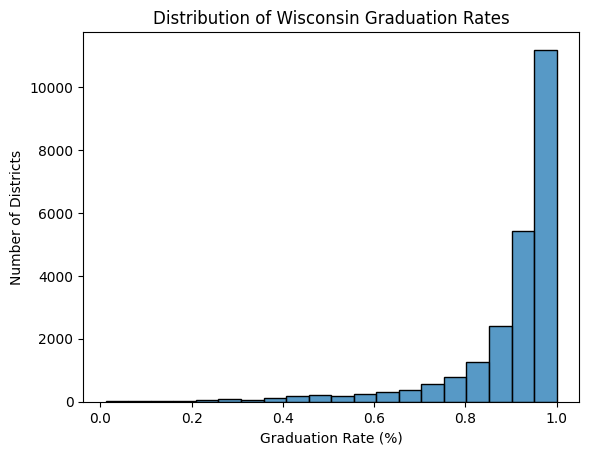

In [12]:
sns.histplot(graduates['GRAD_RATE'], bins=20)
plt.title('Distribution of Wisconsin Graduation Rates')
plt.xlabel('Graduation Rate (%)')
plt.ylabel('Number of Districts')
plt.show()

In [13]:
yearly = graduates.groupby('SCHOOL_YEAR')['GRAD_RATE'].agg(['mean', 'median']).reset_index()

In [14]:
yearly['pct_change'] = yearly['mean'].pct_change() * 100
yearly

,SCHOOL_YEAR,mean,median,pct_change
0,2018-19,0.891937,0.941176,NaN
1,2019-20,0.898592,0.946694,0.746164
2,2020-21,0.883913,0.938900,-1.633530
3,2021-22,0.892841,0.941860,1.010062
4,2022-23,0.894854,0.948052,0.225462
5,2023-24,0.902994,0.950450,0.909579
6,2024-25,0.915780,0.958333,1.416021


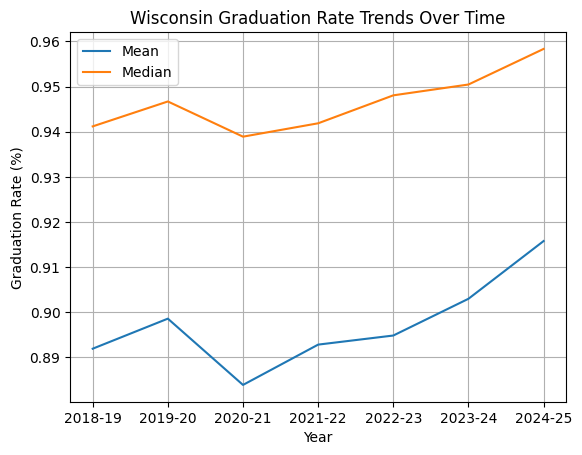

In [15]:
sns.lineplot(data=yearly, x='SCHOOL_YEAR', y='mean', label='Mean')
sns.lineplot(data=yearly, x='SCHOOL_YEAR', y='median', label='Median')
plt.title('Wisconsin Graduation Rate Trends Over Time')
plt.ylabel('Graduation Rate (%)')
plt.xlabel('Year')
plt.legend()
plt.grid()
plt.show()

#Subgroup Graduation Rates

In [16]:
graduates_wide = graduates.pivot_table(index=['DISTRICT_NAME', 'SCHOOL_YEAR', 'CESA'],columns='GROUP_BY_VALUE',values='GRAD_RATE').reset_index()
graduates_wide

GROUP_BY_VALUE,DISTRICT_NAME,SCHOOL_YEAR,CESA,All Students,Amer Indian,Asian,Black,EL,ELL/LEP,Econ Disadv,Eng Prof,Female,Hispanic,Male,Not Econ Disadv,Not Migrant,SwD,SwoD,Two or More,White
0,Abbotsford,2018-19,10.0,0.984375,NaN,NaN,NaN,NaN,NaN,0.974359,0.982759,1.00000,NaN,0.966667,1.000000,0.984375,NaN,NaN,NaN,1.000000
1,Abbotsford,2019-20,10.0,0.976190,NaN,NaN,NaN,NaN,NaN,NaN,0.970588,NaN,NaN,NaN,NaN,0.976190,NaN,NaN,NaN,0.960000
2,Abbotsford,2020-21,10.0,0.981132,NaN,NaN,NaN,NaN,NaN,NaN,0.976190,1.00000,1.0,0.961538,1.000000,0.981132,NaN,NaN,NaN,NaN
3,Abbotsford,2021-22,10.0,0.980000,NaN,NaN,NaN,NaN,NaN,NaN,0.975000,NaN,NaN,0.962963,1.000000,0.980000,NaN,0.977273,NaN,1.000000
4,Abbotsford,2022-23,10.0,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.00000,1.0,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,Wrightstown Community,2020-21,7.0,0.981651,NaN,NaN,NaN,NaN,NaN,NaN,0.981651,1.00000,NaN,0.966102,1.000000,0.981651,NaN,0.990291,NaN,NaN
2378,Wrightstown Community,2021-22,7.0,0.935780,NaN,NaN,NaN,NaN,NaN,0.862069,NaN,0.95082,NaN,0.916667,0.962500,0.935780,NaN,0.941176,NaN,0.946809
2379,Wrightstown Community,2022-23,7.0,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00000,NaN,1.000000,1.000000,1.000000,NaN,1.000000,NaN,1.000000
2380,Wrightstown Community,2023-24,7.0,0.962264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.00000,NaN,0.933333,0.975904,0.962264,NaN,0.979167,NaN,0.978947


In [17]:
exclude = ['EL', 'ELL/LEP', 'Not Migrant', 'Migrant','Eng Prof']
filtered = graduates[~graduates['GROUP_BY_VALUE'].isin(exclude)]

In [18]:
filtered

,SCHOOL_YEAR,AGENCY_TYPE,CHARTER_IND,CESA,COUNTY,DISTRICT_CODE,SCHOOL_CODE,GRADE_GROUP,DISTRICT_NAME,SCHOOL_NAME,COHORT,COMPLETION_STATUS,GROUP_BY,GROUP_BY_VALUE,TIMEFRAME,COHORT_COUNT,STUDENT_COUNT,GRAD_RATE
0,2018-19,Public school,No,10.0,Clark,7,40.0,High School,Abbotsford,Abbotsford Middle/Senior High,2019,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,64,63,0.984375
2,2018-19,Public school,No,10.0,Clark,7,40.0,High School,Abbotsford,Abbotsford Middle/Senior High,2019,Completed - Regular High School Diploma,Economic Status,Econ Disadv,4-Year rate,39,38,0.974359
4,2018-19,Public school,No,10.0,Clark,7,40.0,High School,Abbotsford,Abbotsford Middle/Senior High,2019,Completed - Regular High School Diploma,Economic Status,Not Econ Disadv,4-Year rate,25,25,1.000000
7,2018-19,Public school,No,10.0,Clark,7,40.0,High School,Abbotsford,Abbotsford Middle/Senior High,2019,Completed - Regular High School Diploma,Gender,Female,4-Year rate,34,34,1.000000
8,2018-19,Public school,No,10.0,Clark,7,40.0,High School,Abbotsford,Abbotsford Middle/Senior High,2019,Completed - Regular High School Diploma,Gender,Male,4-Year rate,30,29,0.966667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62011,2024-25,Public school,No,7.0,Brown,6734,40.0,High School,Wrightstown Community,Wrightstown High,2025,Completed - Regular High School Diploma,Disability Status,SwoD,4-Year rate,83,83,1.000000
62012,2024-25,Public school,No,7.0,Brown,6734,40.0,High School,Wrightstown Community,Wrightstown High,2025,Completed - Regular High School Diploma,Economic Status,Not Econ Disadv,4-Year rate,78,78,1.000000
62013,2024-25,Public school,No,7.0,Brown,6734,40.0,High School,Wrightstown Community,Wrightstown High,2025,Completed - Regular High School Diploma,Gender,Female,4-Year rate,42,42,1.000000
62014,2024-25,Public school,No,7.0,Brown,6734,40.0,High School,Wrightstown Community,Wrightstown High,2025,Completed - Regular High School Diploma,Gender,Male,4-Year rate,52,52,1.000000


In [19]:
filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18432 entries, 0 to 62016
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   SCHOOL_YEAR        18432 non-null  object 
 1   AGENCY_TYPE        18432 non-null  object 
 2   CHARTER_IND        18432 non-null  object 
 3   CESA               18432 non-null  float64
 4   COUNTY             18432 non-null  object 
 5   DISTRICT_CODE      18432 non-null  int64  
 6   SCHOOL_CODE        18432 non-null  float64
 7   GRADE_GROUP        18432 non-null  object 
 8   DISTRICT_NAME      18432 non-null  object 
 9   SCHOOL_NAME        18432 non-null  object 
 10  COHORT             18432 non-null  int64  
 11  COMPLETION_STATUS  18432 non-null  object 
 12  GROUP_BY           18432 non-null  object 
 13  GROUP_BY_VALUE     18432 non-null  object 
 14  TIMEFRAME          18432 non-null  object 
 15  COHORT_COUNT       18432 non-null  int64  
 16  STUDENT_COUNT      18432 no

In [20]:
subgroup_summary = filtered.groupby(['GROUP_BY_VALUE'])['GRAD_RATE'].agg(['mean', 'median', 'count']).reset_index()
subgroup_summary

,GROUP_BY_VALUE,mean,median,count
0,All Students,0.904380,0.948454,3137
1,Amer Indian,0.816497,0.828571,35
2,Asian,0.927502,0.947368,214
3,Black,0.729331,0.760952,396
4,Econ Disadv,0.848299,0.891033,1804
5,Female,0.920115,0.959776,2250
6,Hispanic,0.841850,0.878788,611
7,Male,0.894609,0.939024,2349
8,Not Econ Disadv,0.949241,0.970588,2398
9,SwD,0.706963,0.750000,785


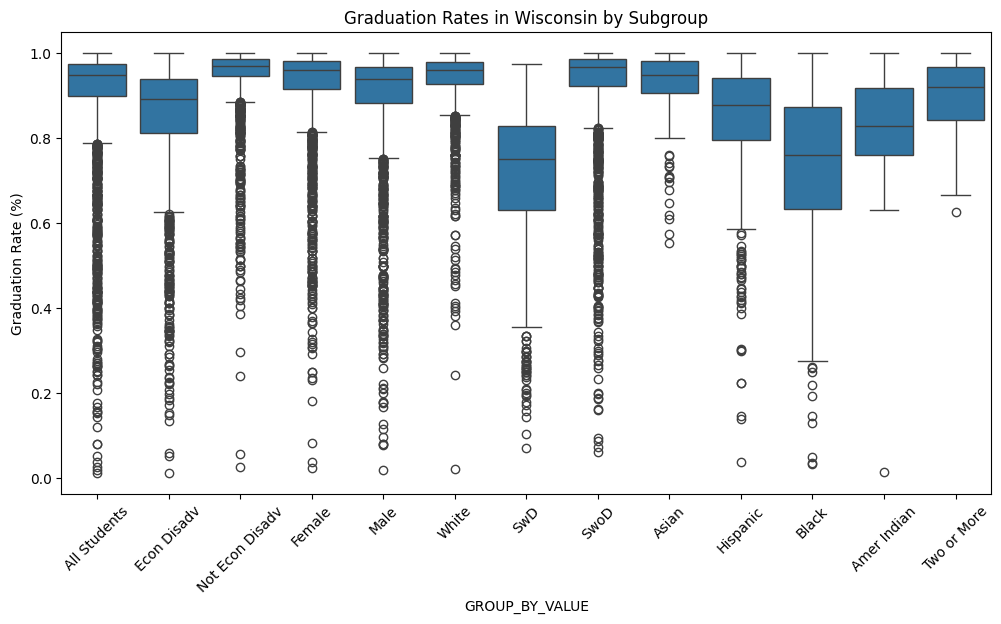

In [21]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=filtered, x='GROUP_BY_VALUE', y='GRAD_RATE')
plt.xticks(rotation=45)
plt.title('Graduation Rates in Wisconsin by Subgroup')
plt.ylabel('Graduation Rate (%)')
plt.show()

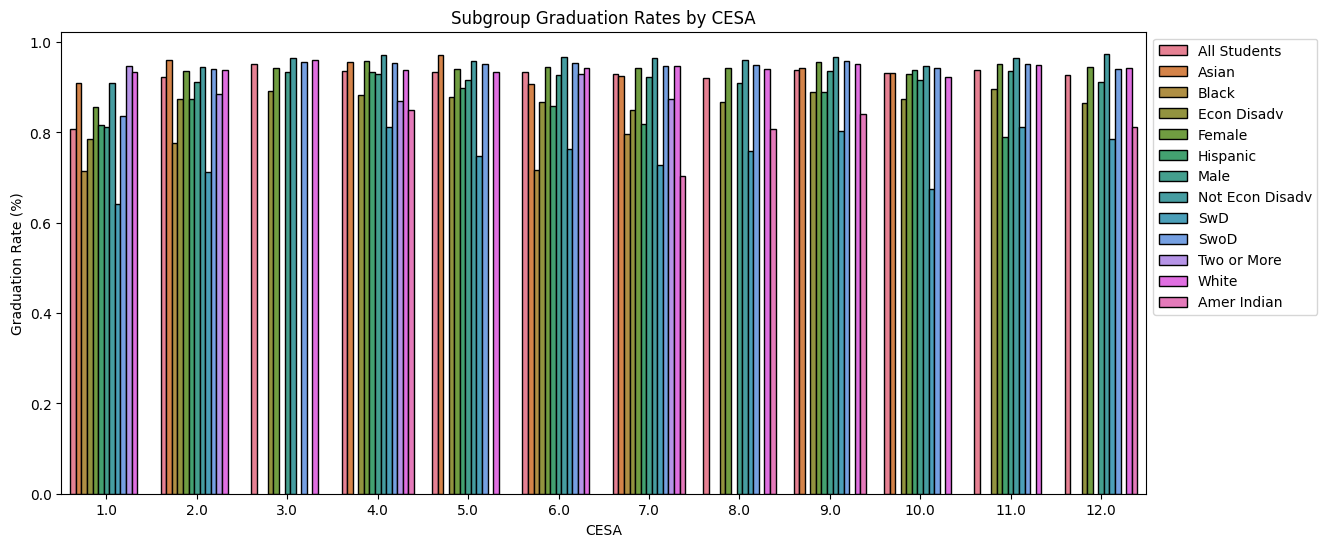

In [22]:
cesa_subgroup = (filtered.groupby(['CESA', 'GROUP_BY_VALUE'])['GRAD_RATE'].mean().reset_index())

plt.figure(figsize=(14, 6))
sns.barplot(data=cesa_subgroup, x='CESA', y='GRAD_RATE', hue='GROUP_BY_VALUE',edgecolor='black')
plt.title("Subgroup Graduation Rates by CESA")
plt.ylabel("Graduation Rate (%)")
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

#Forward Correlation with 3 Districts

In [23]:
corr_overall = composite[['AVG_COMPOSITE', 'GRAD_RATE']].corr()
corr_overall

,AVG_COMPOSITE,GRAD_RATE
AVG_COMPOSITE,1.000000,0.761009
GRAD_RATE,0.761009,1.000000


In [172]:
corr_by_subject = composite_merged.groupby('TEST_SUBJECT')[['Composite_Score', 'GRAD_RATE']].corr().reset_index()
corr_by_subject

,TEST_SUBJECT,level_1,Composite_Score,GRAD_RATE
0,ELA,Composite_Score,1.000000,0.777984
1,ELA,GRAD_RATE,0.777984,1.000000
2,Mathematics,Composite_Score,1.000000,0.759214
3,Mathematics,GRAD_RATE,0.759214,1.000000
4,Science,Composite_Score,1.000000,0.770470
5,Science,GRAD_RATE,0.770470,1.000000
6,Social Studies,Composite_Score,1.000000,0.760805
7,Social Studies,GRAD_RATE,0.760805,1.000000


In [174]:
corr_clean = corr_by_subject[corr_by_subject['level_1'] == 'Composite_Score']
corr_clean = corr_clean[['TEST_SUBJECT', 'GRAD_RATE']]
corr_clean = corr_clean.rename(columns={'GRAD_RATE': 'Correlation'})

In [176]:
corr_pivot = corr_clean.pivot_table(
    index='TEST_SUBJECT',
    values='Correlation')

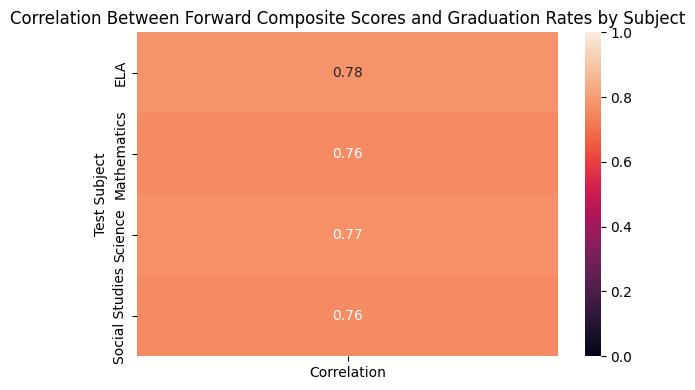

In [177]:
plt.figure(figsize=(6,4))
sns.heatmap(corr_pivot,annot=True,vmin=0,vmax=1)

plt.title("Correlation Between Forward Composite Scores and Graduation Rates by Subject")
plt.xlabel("")
plt.ylabel("Test Subject")
plt.tight_layout()
plt.show()

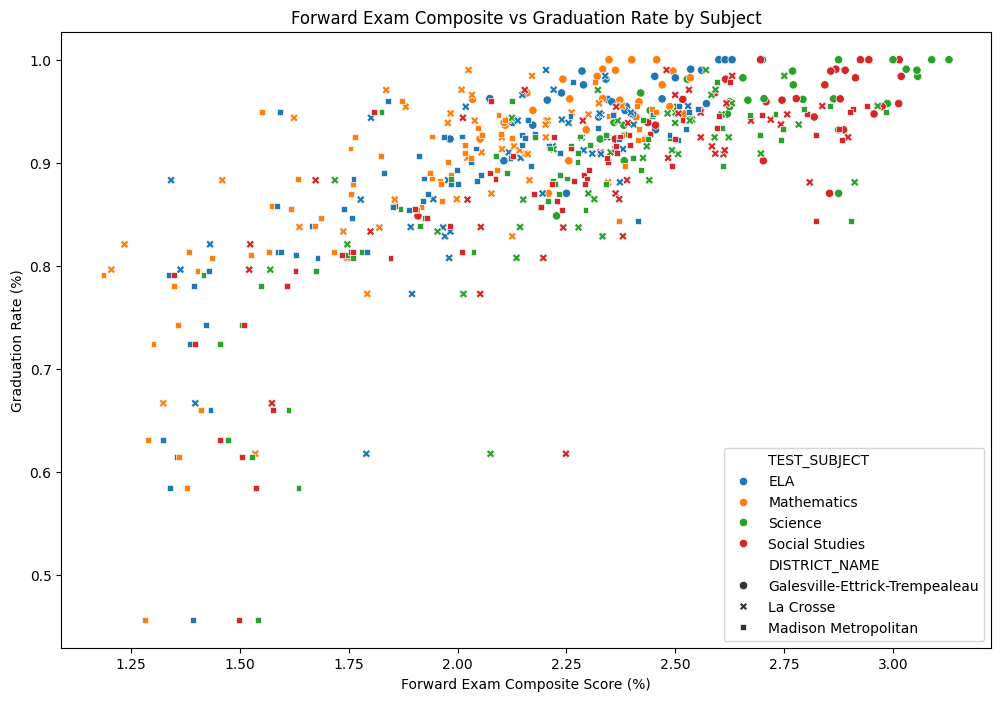

In [25]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=composite_merged,x='Composite_Score',y='GRAD_RATE',hue='TEST_SUBJECT',style='DISTRICT_NAME')
plt.title("Forward Exam Composite vs Graduation Rate by Subject")
plt.xlabel("Forward Exam Composite Score (%)")
plt.ylabel("Graduation Rate (%)")
plt.show()

In [26]:
district_corr = (composite_merged.groupby('DISTRICT_NAME')[['Composite_Score', 'GRAD_RATE']].corr().reset_index().rename(columns={'GRAD_RATE': 'Correlation'}))

district_corr

,DISTRICT_NAME,level_1,Composite_Score,Correlation
0,Galesville-Ettrick-Trempealeau,Composite_Score,1.000000,0.449778
1,Galesville-Ettrick-Trempealeau,GRAD_RATE,0.449778,1.000000
2,La Crosse,Composite_Score,1.000000,0.558007
3,La Crosse,GRAD_RATE,0.558007,1.000000
4,Madison Metropolitan,Composite_Score,1.000000,0.712253
5,Madison Metropolitan,GRAD_RATE,0.712253,1.000000


In [155]:
district_sub_corr = composite_merged.groupby(['DISTRICT_NAME', 'TEST_SUBJECT'])[['Composite_Score', 'GRAD_RATE']].corr().reset_index().rename(columns={'GRAD_RATE': 'Correlation'})   # extract correlation with GRAD_RATE.reset_index().rename(columns={'GRAD_RATE': 'Correlation'}))
district_sub_corr

,DISTRICT_NAME,TEST_SUBJECT,level_2,Composite_Score,Correlation
0,Galesville-Ettrick-Trempealeau,ELA,Composite_Score,1.000000,0.723387
1,Galesville-Ettrick-Trempealeau,ELA,GRAD_RATE,0.723387,1.000000
2,Galesville-Ettrick-Trempealeau,Mathematics,Composite_Score,1.000000,0.595494
3,Galesville-Ettrick-Trempealeau,Mathematics,GRAD_RATE,0.595494,1.000000
4,Galesville-Ettrick-Trempealeau,Science,Composite_Score,1.000000,0.604435
5,Galesville-Ettrick-Trempealeau,Science,GRAD_RATE,0.604435,1.000000
6,Galesville-Ettrick-Trempealeau,Social Studies,Composite_Score,1.000000,0.585788
7,Galesville-Ettrick-Trempealeau,Social Studies,GRAD_RATE,0.585788,1.000000
8,La Crosse,ELA,Composite_Score,1.000000,0.646171
9,La Crosse,ELA,GRAD_RATE,0.646171,1.000000


In [161]:
corr_table = (
    composite_merged
        .groupby(['DISTRICT_NAME', 'TEST_SUBJECT'])[['Composite_Score', 'GRAD_RATE']]
        .corr()
        .reset_index())

corr_table = corr_table[corr_table['level_2'] == 'Composite_Score']

corr_table = corr_table[['DISTRICT_NAME', 'TEST_SUBJECT', 'GRAD_RATE']]
corr_table = corr_table.rename(columns={'GRAD_RATE': 'Correlation'})

corr_table

,DISTRICT_NAME,TEST_SUBJECT,Correlation
0,Galesville-Ettrick-Trempealeau,ELA,0.723387
2,Galesville-Ettrick-Trempealeau,Mathematics,0.595494
4,Galesville-Ettrick-Trempealeau,Science,0.604435
6,Galesville-Ettrick-Trempealeau,Social Studies,0.585788
8,La Crosse,ELA,0.646171
10,La Crosse,Mathematics,0.639878
12,La Crosse,Science,0.689394
14,La Crosse,Social Studies,0.587307
16,Madison Metropolitan,ELA,0.769587
18,Madison Metropolitan,Mathematics,0.742303


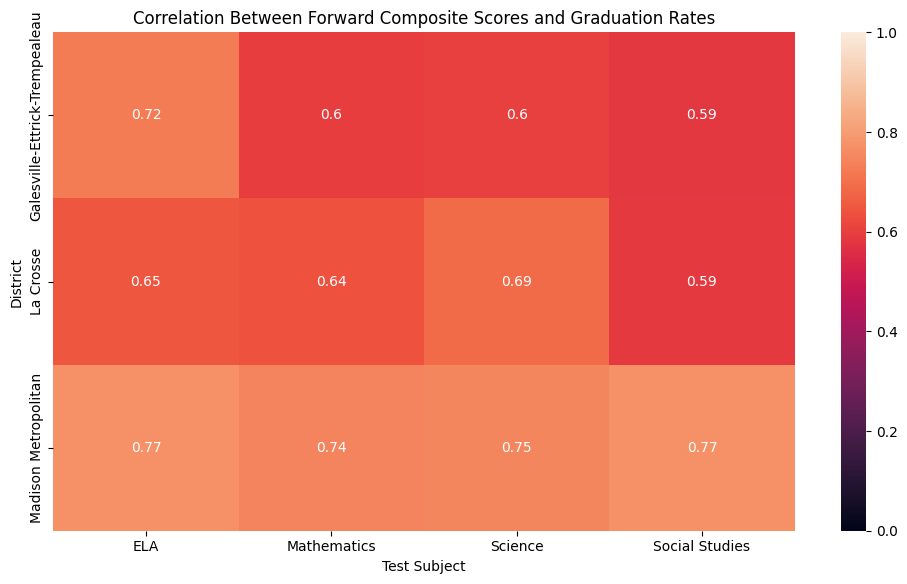

In [163]:
corr_pivot = corr_table.pivot(index='DISTRICT_NAME', columns='TEST_SUBJECT', values='Correlation')

plt.figure(figsize=(10,6))
sns.heatmap(corr_pivot, annot=True, vmin=0, vmax=1)
plt.title("Correlation Between Forward Composite Scores and Graduation Rates")
plt.ylabel("District")
plt.xlabel("Test Subject")
plt.tight_layout()
plt.show()

#Comparing CESAs

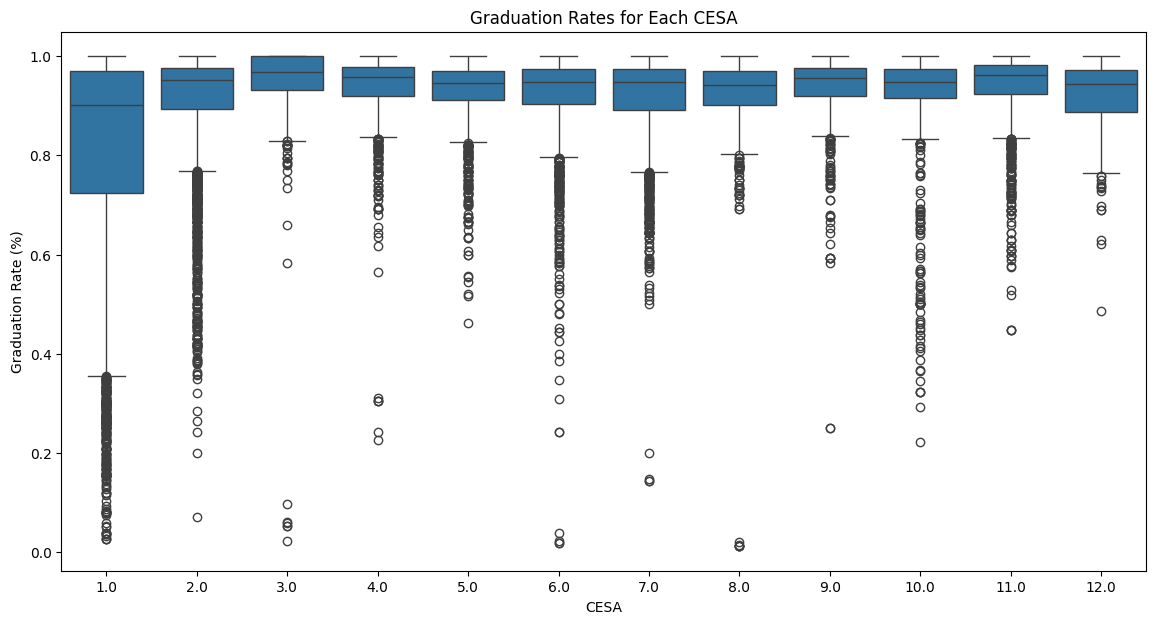

In [28]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=graduates,x='CESA',y='GRAD_RATE')
plt.title('Graduation Rates for Each CESA')
plt.xlabel('CESA')
plt.ylabel('Graduation Rate (%)')
plt.show()

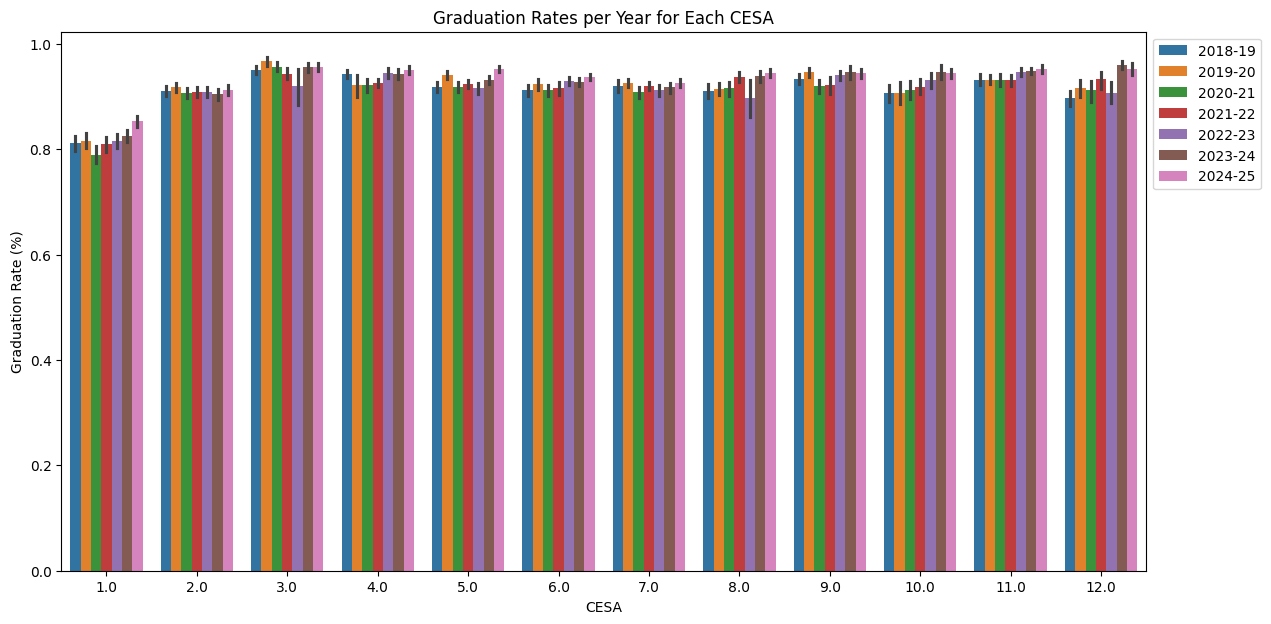

In [29]:
plt.figure(figsize=(14, 7))
sns.barplot(data=graduates,x='CESA',y='GRAD_RATE',hue='SCHOOL_YEAR')
plt.title('Graduation Rates per Year for Each CESA')
plt.xlabel('CESA')
plt.ylabel('Graduation Rate (%)')
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

#Linear Regression Setup

###Group 1

In [30]:
filtered[~filtered.duplicated(subset=['CESA','DISTRICT_CODE','SCHOOL_CODE'])]

,SCHOOL_YEAR,AGENCY_TYPE,CHARTER_IND,CESA,COUNTY,DISTRICT_CODE,SCHOOL_CODE,GRADE_GROUP,DISTRICT_NAME,SCHOOL_NAME,COHORT,COMPLETION_STATUS,GROUP_BY,GROUP_BY_VALUE,TIMEFRAME,COHORT_COUNT,STUDENT_COUNT,GRAD_RATE
0,2018-19,Public school,No,10.0,Clark,7,40.0,High School,Abbotsford,Abbotsford Middle/Senior High,2019,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,64,63,0.984375
13,2018-19,Public school,No,5.0,Adams,14,40.0,High School,Adams-Friendship Area,Adams-Friendship High,2019,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,134,124,0.925373
38,2018-19,Public school,No,2.0,Green,63,40.0,High School,Albany,Albany High,2019,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,25,23,0.920000
42,2018-19,Public school,No,7.0,Kewaunee,70,40.0,High School,Algoma,Algoma High,2019,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,59,57,0.966102
59,2018-19,Public school,No,4.0,Jackson,91,60.0,High School,Alma Center,Lincoln High,2019,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,37,33,0.891892
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57802,2024-25,Public school,Yes,1.0,Milwaukee,3619,454.0,High School,Milwaukee,Green Tree Preparatory Academy,2025,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,49,42,0.857143
58946,2024-25,Public school,Yes,9.0,Vilas,1526,410.0,High School,Northland Pines,School of Options and Applied Research High,2025,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,31,30,0.967742
59302,2024-25,Public school,Yes,2.0,Rock,4151,800.0,Combined Elementary/Secondary School,Parkview,Parkview Academy of Virtual Education,2025,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,29,26,0.896552
60806,2024-25,Non District Charter Schools,Yes,2.0,Rock,8023,8149.0,Combined Elementary/Secondary School,The Lincoln Academy Inc,The Lincoln Academy,2025,Completed - Regular High School Diploma,All Students,All Students,4-Year rate,50,50,1.000000


In [31]:
filtered['DISTRICT_CODE'].unique().size

365

In [32]:
filtered['SCHOOL_CODE'].unique().size

108

In [33]:
filtered_pk = filtered.copy()
filtered_pk['pk'] = filtered_pk['DISTRICT_CODE'].astype(int).astype(str) + filtered_pk['SCHOOL_CODE'].astype(int).astype(str)
filtered_pk['pk'] = filtered_pk['pk'].astype(int)
filtered_pk['pk'].unique().size

502

In [34]:
df = filtered_pk.copy()

In [35]:
filtered['GROUP_BY_VALUE'].unique()

array(['All Students', 'Econ Disadv', 'Not Econ Disadv', 'Female', 'Male',
       'White', 'SwD', 'SwoD', 'Asian', 'Hispanic', 'Black',
       'Amer Indian', 'Two or More'], dtype=object)

In [36]:
filtered_pk['GROUP_BY_VALUE'].unique()

array(['All Students', 'Econ Disadv', 'Not Econ Disadv', 'Female', 'Male',
       'White', 'SwD', 'SwoD', 'Asian', 'Hispanic', 'Black',
       'Amer Indian', 'Two or More'], dtype=object)

In [37]:
keep= ['All Students','Male','Econ Disadv','SwD','Hispanic','Black','Asian']

In [38]:
filtered_pk = filtered_pk[filtered_pk.GROUP_BY_VALUE.isin(keep)].reset_index(drop=True)

In [39]:
filtered_pk = filtered_pk[['pk', 'CESA','COHORT','GROUP_BY','GROUP_BY_VALUE','COHORT_COUNT','STUDENT_COUNT','GRAD_RATE']]

In [40]:
filtered_pk

,pk,CESA,COHORT,GROUP_BY,GROUP_BY_VALUE,COHORT_COUNT,STUDENT_COUNT,GRAD_RATE
0,740,10.0,2019,All Students,All Students,64,63,0.984375
1,740,10.0,2019,Economic Status,Econ Disadv,39,38,0.974359
2,740,10.0,2019,Gender,Male,30,29,0.966667
3,1440,5.0,2019,All Students,All Students,134,124,0.925373
4,1440,5.0,2019,Disability Status,SwD,32,29,0.906250
...,...,...,...,...,...,...,...,...
9291,6692140,8.0,2025,Economic Status,Econ Disadv,39,37,0.948718
9292,6692140,8.0,2025,Gender,Male,44,41,0.931818
9293,671380,4.0,2025,All Students,All Students,29,29,1.000000
9294,673440,7.0,2025,All Students,All Students,94,94,1.000000


In [41]:
filtered_pk_rates = filtered_pk.pivot(index=['pk','CESA','COHORT'], columns='GROUP_BY_VALUE', values='GRAD_RATE').reset_index()
filtered_pk_counts = filtered_pk.pivot(index=['pk','CESA','COHORT'], columns='GROUP_BY_VALUE', values='STUDENT_COUNT').reset_index()

In [42]:
cats = filtered_pk_counts.columns[4:]
cats = list(cats)
cats

['Asian', 'Black', 'Econ Disadv', 'Hispanic', 'Male', 'SwD']

In [43]:
filtered_pk_counts[cats]

GROUP_BY_VALUE,Asian,Black,Econ Disadv,Hispanic,Male,SwD
0,NaN,NaN,38.0,NaN,29.0,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,26.0,25.0,NaN
3,NaN,NaN,NaN,NaN,26.0,NaN
4,NaN,NaN,35.0,35.0,NaN,NaN
...,...,...,...,...,...,...
3132,NaN,NaN,30.0,NaN,21.0,NaN
3133,NaN,NaN,31.0,NaN,NaN,NaN
3134,NaN,NaN,55.0,NaN,25.0,NaN
3135,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
cols = ['Black','Econ Disadv','Male','SwD','Hispanic','Asian']
filtered_pk_counts.loc[:, cols] = filtered_pk_counts[cols].mask(filtered_pk_counts[cols] < 5)

In [45]:
filtered_pk_counts[cats] = filtered_pk_counts[cats].div(filtered_pk_counts['All Students'],axis=0)
filtered_pk_counts

GROUP_BY_VALUE,pk,CESA,COHORT,All Students,Asian,Black,Econ Disadv,Hispanic,Male,SwD
0,740,10.0,2019,63.0,NaN,NaN,0.603175,NaN,0.460317,NaN
1,740,10.0,2020,41.0,NaN,NaN,NaN,NaN,NaN,NaN
2,740,10.0,2021,52.0,NaN,NaN,NaN,0.500000,0.480769,NaN
3,740,10.0,2022,49.0,NaN,NaN,NaN,NaN,0.530612,NaN
4,740,10.0,2023,55.0,NaN,NaN,0.636364,0.636364,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
3132,81061251,1.0,2020,40.0,NaN,NaN,0.750000,NaN,0.525000,NaN
3133,81061251,1.0,2021,36.0,NaN,NaN,0.861111,NaN,NaN,NaN
3134,81061251,1.0,2022,60.0,NaN,NaN,0.916667,NaN,0.416667,NaN
3135,81398139,1.0,2021,13.0,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
filtered_pk_combo = filtered_pk_counts.join(filtered_pk_rates[['All Students']], how='inner',rsuffix="_rate")
filtered_pk_combo

GROUP_BY_VALUE,pk,CESA,COHORT,All Students,Asian,Black,Econ Disadv,Hispanic,Male,SwD,All Students_rate
0,740,10.0,2019,63.0,NaN,NaN,0.603175,NaN,0.460317,NaN,0.984375
1,740,10.0,2020,41.0,NaN,NaN,NaN,NaN,NaN,NaN,0.976190
2,740,10.0,2021,52.0,NaN,NaN,NaN,0.500000,0.480769,NaN,0.981132
3,740,10.0,2022,49.0,NaN,NaN,NaN,NaN,0.530612,NaN,0.980000
4,740,10.0,2023,55.0,NaN,NaN,0.636364,0.636364,NaN,NaN,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
3132,81061251,1.0,2020,40.0,NaN,NaN,0.750000,NaN,0.525000,NaN,0.869565
3133,81061251,1.0,2021,36.0,NaN,NaN,0.861111,NaN,NaN,NaN,0.857143
3134,81061251,1.0,2022,60.0,NaN,NaN,0.916667,NaN,0.416667,NaN,0.895522
3135,81398139,1.0,2021,13.0,NaN,NaN,NaN,NaN,NaN,NaN,0.382353


In [47]:
filtered_pk_combo.shape

(3137, 11)

In [48]:
low = filtered_pk_combo.dropna(subset=['Black', 'Econ Disadv', 'Hispanic', 'Male', 'SwD','Asian']).reset_index(drop=True)
low = low[['Black', 'Econ Disadv', 'Hispanic', 'Male', 'SwD','Asian','All Students_rate']]

In [49]:
low

GROUP_BY_VALUE,Black,Econ Disadv,Hispanic,Male,SwD,Asian,All Students_rate
0,0.051515,0.248485,0.072727,0.496970,0.069697,0.115152,0.850515
1,0.093023,0.413953,0.097674,0.451163,0.111628,0.144186,0.805243
2,0.074219,0.488281,0.128906,0.539062,0.175781,0.167969,0.805031
3,0.072961,0.579399,0.141631,0.523605,0.158798,0.175966,0.817544
4,0.075758,0.446970,0.140152,0.458333,0.193182,0.136364,0.880000
...,...,...,...,...,...,...,...
66,0.083821,0.235867,0.081871,0.506823,0.083821,0.077973,0.958879
67,0.082218,0.210325,0.089866,0.512428,0.105163,0.061185,0.966728
68,0.070450,0.191781,0.082192,0.524462,0.090020,0.072407,0.969639
69,0.158940,0.337748,0.099338,0.543046,0.105960,0.152318,0.961783


In [50]:
X = low[['Black','Econ Disadv','Hispanic','Male','SwD','Asian']]
y = low['All Students_rate']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state = 2026)

In [52]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [53]:
r2low = model.score(X_test,y_test)
r2low

0.6588787878800457

In [54]:
low['y_pred'] = model.predict(X)
low

GROUP_BY_VALUE,Black,Econ Disadv,Hispanic,Male,SwD,Asian,All Students_rate,y_pred
0,0.051515,0.248485,0.072727,0.496970,0.069697,0.115152,0.850515,0.984124
1,0.093023,0.413953,0.097674,0.451163,0.111628,0.144186,0.805243,0.943743
2,0.074219,0.488281,0.128906,0.539062,0.175781,0.167969,0.805031,0.786070
3,0.072961,0.579399,0.141631,0.523605,0.158798,0.175966,0.817544,0.802821
4,0.075758,0.446970,0.140152,0.458333,0.193182,0.136364,0.880000,0.851252
...,...,...,...,...,...,...,...,...
66,0.083821,0.235867,0.081871,0.506823,0.083821,0.077973,0.958879,0.986050
67,0.082218,0.210325,0.089866,0.512428,0.105163,0.061185,0.966728,0.971935
68,0.070450,0.191781,0.082192,0.524462,0.090020,0.072407,0.969639,0.971207
69,0.158940,0.337748,0.099338,0.543046,0.105960,0.152318,0.961783,0.850711


In [55]:
X.corrwith(y)

,0
GROUP_BY_VALUE,
Black,-0.285070
Econ Disadv,-0.678555
Hispanic,-0.750768
Male,-0.071151
SwD,-0.288290
Asian,-0.624167


In [56]:
X.corr()

GROUP_BY_VALUE,Black,Econ Disadv,Hispanic,Male,SwD,Asian
GROUP_BY_VALUE,,,,,,
Black,1.000000,0.483654,0.193247,-0.475914,-0.009414,0.224448
Econ Disadv,0.483654,1.000000,0.680594,-0.024706,0.282616,0.517887
Hispanic,0.193247,0.680594,1.000000,0.009336,0.086348,0.395785
Male,-0.475914,-0.024706,0.009336,1.000000,-0.059352,-0.096739
SwD,-0.009414,0.282616,0.086348,-0.059352,1.000000,0.197032
Asian,0.224448,0.517887,0.395785,-0.096739,0.197032,1.000000


<Axes: xlabel='GROUP_BY_VALUE'>

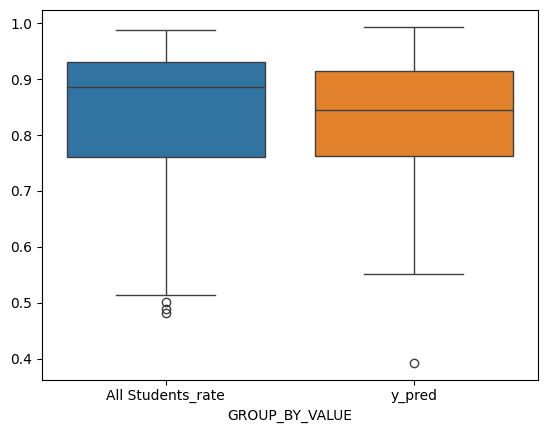

In [57]:
sns.boxplot(low[['All Students_rate','y_pred']])

###Group 2

In [58]:
filtered_pk2 = filtered.copy()
filtered_pk2['pk'] = filtered_pk2['DISTRICT_CODE'].astype(int).astype(str) + filtered_pk2['SCHOOL_CODE'].astype(int).astype(str)
filtered_pk2['pk'] = filtered_pk2['pk'].astype(int)
filtered_pk2['pk'].unique().size

502

In [59]:
filtered_pk2['GROUP_BY_VALUE'].unique()

array(['All Students', 'Econ Disadv', 'Not Econ Disadv', 'Female', 'Male',
       'White', 'SwD', 'SwoD', 'Asian', 'Hispanic', 'Black',
       'Amer Indian', 'Two or More'], dtype=object)

In [60]:
keep2 = ['All Students','Female','Not Econ Disadv','White', 'SwoD']

In [61]:
filtered_pk2 = filtered_pk2[filtered_pk2.GROUP_BY_VALUE.isin(keep2)].reset_index(drop=True)

In [62]:
filtered_pk2 = filtered_pk2[['pk', 'CESA','COHORT','GROUP_BY','GROUP_BY_VALUE','COHORT_COUNT','STUDENT_COUNT','GRAD_RATE']]

In [63]:
filtered_pk2

,pk,CESA,COHORT,GROUP_BY,GROUP_BY_VALUE,COHORT_COUNT,STUDENT_COUNT,GRAD_RATE
0,740,10.0,2019,All Students,All Students,64,63,0.984375
1,740,10.0,2019,Economic Status,Not Econ Disadv,25,25,1.000000
2,740,10.0,2019,Gender,Female,34,34,1.000000
3,740,10.0,2019,Race/Ethnicity,White,34,34,1.000000
4,1440,5.0,2019,All Students,All Students,134,124,0.925373
...,...,...,...,...,...,...,...,...
12182,673440,7.0,2025,All Students,All Students,94,94,1.000000
12183,673440,7.0,2025,Disability Status,SwoD,83,83,1.000000
12184,673440,7.0,2025,Economic Status,Not Econ Disadv,78,78,1.000000
12185,673440,7.0,2025,Gender,Female,42,42,1.000000


In [64]:
filtered_pk_rates2 = filtered_pk2.pivot(index=['pk','CESA','COHORT'], columns='GROUP_BY_VALUE', values='GRAD_RATE').reset_index()
filtered_pk_counts2 = filtered_pk2.pivot(index=['pk','CESA','COHORT'], columns='GROUP_BY_VALUE', values='STUDENT_COUNT').reset_index()

In [65]:
cats2 = filtered_pk_counts2.columns[4:]
cats2 = list(cats2)
cats2

['Female', 'Not Econ Disadv', 'SwoD', 'White']

In [66]:
filtered_pk_counts2[cats2]

GROUP_BY_VALUE,Female,Not Econ Disadv,SwoD,White
0,34.0,25.0,NaN,34.0
1,NaN,NaN,NaN,24.0
2,27.0,32.0,NaN,NaN
3,NaN,26.0,43.0,26.0
4,35.0,NaN,48.0,NaN
...,...,...,...,...
3132,NaN,NaN,NaN,NaN
3133,NaN,NaN,NaN,NaN
3134,35.0,NaN,54.0,NaN
3135,NaN,NaN,NaN,NaN


In [67]:
cols2 = ['White','Not Econ Disadv','Female','SwoD']
filtered_pk_counts2.loc[:, cols2] = filtered_pk_counts2[cols2].mask(filtered_pk_counts2[cols2] < 5)

In [68]:
filtered_pk_counts2[cats2] = filtered_pk_counts2[cats2].div(filtered_pk_counts2['All Students'],axis=0)
filtered_pk_counts2

GROUP_BY_VALUE,pk,CESA,COHORT,All Students,Female,Not Econ Disadv,SwoD,White
0,740,10.0,2019,63.0,0.539683,0.396825,NaN,0.539683
1,740,10.0,2020,41.0,NaN,NaN,NaN,0.585366
2,740,10.0,2021,52.0,0.519231,0.615385,NaN,NaN
3,740,10.0,2022,49.0,NaN,0.530612,0.877551,0.530612
4,740,10.0,2023,55.0,0.636364,NaN,0.872727,NaN
...,...,...,...,...,...,...,...,...
3132,81061251,1.0,2020,40.0,NaN,NaN,NaN,NaN
3133,81061251,1.0,2021,36.0,NaN,NaN,NaN,NaN
3134,81061251,1.0,2022,60.0,0.583333,NaN,0.900000,NaN
3135,81398139,1.0,2021,13.0,NaN,NaN,NaN,NaN


In [69]:
filtered_pk_combo2 = filtered_pk_counts2.join(filtered_pk_rates2[['All Students']], how='inner',rsuffix="_rate")
filtered_pk_combo2

GROUP_BY_VALUE,pk,CESA,COHORT,All Students,Female,Not Econ Disadv,SwoD,White,All Students_rate
0,740,10.0,2019,63.0,0.539683,0.396825,NaN,0.539683,0.984375
1,740,10.0,2020,41.0,NaN,NaN,NaN,0.585366,0.976190
2,740,10.0,2021,52.0,0.519231,0.615385,NaN,NaN,0.981132
3,740,10.0,2022,49.0,NaN,0.530612,0.877551,0.530612,0.980000
4,740,10.0,2023,55.0,0.636364,NaN,0.872727,NaN,1.000000
...,...,...,...,...,...,...,...,...,...
3132,81061251,1.0,2020,40.0,NaN,NaN,NaN,NaN,0.869565
3133,81061251,1.0,2021,36.0,NaN,NaN,NaN,NaN,0.857143
3134,81061251,1.0,2022,60.0,0.583333,NaN,0.900000,NaN,0.895522
3135,81398139,1.0,2021,13.0,NaN,NaN,NaN,NaN,0.382353


In [70]:
filtered_pk_combo2.shape

(3137, 9)

In [71]:
high = filtered_pk_combo2.dropna(subset=['White', 'Not Econ Disadv', 'SwoD','Female']).reset_index(drop=True)
high = high[['White', 'Not Econ Disadv', 'SwoD','Female','All Students_rate']]

In [72]:
X2 = high[['White', 'Not Econ Disadv', 'SwoD','Female']]
y2 = high['All Students_rate']

In [73]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = .2, random_state = 2026)

In [74]:
model2 = LinearRegression()
model2.fit(X_train2,y_train2)

LinearRegression()

In [75]:
r2high = model2.score(X_test2,y_test2)
r2high

0.35995177864492367

In [76]:
high['y_pred'] = model2.predict(X2)
high

GROUP_BY_VALUE,White,Not Econ Disadv,SwoD,Female,All Students_rate,y_pred
0,0.895161,0.362903,0.766129,0.451613,0.925373,0.888428
1,0.910891,0.415842,0.821782,0.435644,0.935185,0.902302
2,0.880000,0.350000,0.850000,0.450000,0.917431,0.885066
3,0.917431,0.348624,0.862385,0.467890,0.872000,0.884893
4,0.836207,0.448276,0.836207,0.465517,0.950820,0.896511
...,...,...,...,...,...,...
1572,0.833333,0.558824,0.823529,0.460784,0.927273,0.917310
1573,0.888889,0.539683,0.777778,0.603175,0.926471,0.893456
1574,0.917808,0.630137,0.863014,0.506849,0.948052,0.929525
1575,0.850575,0.563218,0.850575,0.597701,1.000000,0.895436


In [77]:
X2.corrwith(y2)

,0
GROUP_BY_VALUE,
White,0.467088
Not Econ Disadv,0.547310
SwoD,0.159306
Female,-0.209445


In [78]:
X2.corr()

GROUP_BY_VALUE,White,Not Econ Disadv,SwoD,Female
GROUP_BY_VALUE,,,,
White,1.000000,0.595856,0.106861,-0.164645
Not Econ Disadv,0.595856,1.000000,0.387578,-0.119105
SwoD,0.106861,0.387578,1.000000,0.089276
Female,-0.164645,-0.119105,0.089276,1.000000


<Axes: xlabel='GROUP_BY_VALUE'>

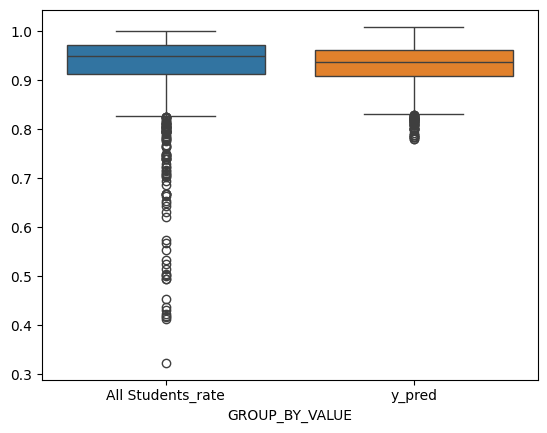

In [79]:
sns.boxplot(high[['All Students_rate','y_pred']])

###Groups Together

In [80]:
high_low = high.merge(low,
    on=['All Students_rate'],
    how='inner')

In [81]:
high_low

GROUP_BY_VALUE,White,Not Econ Disadv,SwoD,Female,All Students_rate,y_pred_x,Black,Econ Disadv,Hispanic,Male,SwD,Asian,y_pred_y
0,0.736364,0.751515,0.930303,0.503030,0.850515,0.936739,0.051515,0.248485,0.072727,0.496970,0.069697,0.115152,0.984124
1,0.641860,0.586047,0.888372,0.548837,0.805243,0.890218,0.093023,0.413953,0.097674,0.451163,0.111628,0.144186,0.943743
2,0.582031,0.511719,0.824219,0.460938,0.805031,0.886960,0.074219,0.488281,0.128906,0.539062,0.175781,0.167969,0.786070
3,0.562232,0.420601,0.841202,0.476395,0.817544,0.865863,0.072961,0.579399,0.141631,0.523605,0.158798,0.175966,0.802821
4,0.602273,0.553030,0.806818,0.541667,0.880000,0.882005,0.075758,0.446970,0.140152,0.458333,0.193182,0.136364,0.851252
5,0.788018,0.682028,0.907834,0.562212,0.907950,0.918040,0.138249,0.288018,0.168203,0.525346,0.101382,0.103687,0.862626
6,0.723077,0.729670,0.927473,0.472527,0.951883,0.936981,0.050549,0.270330,0.098901,0.527473,0.072527,0.083516,0.970721
7,0.692557,0.883495,0.932039,0.459547,0.984076,0.964767,0.093851,0.116505,0.087379,0.540453,0.067961,0.080906,0.955151
8,0.754864,0.824903,0.912451,0.505837,0.957169,0.951257,0.040856,0.175097,0.095331,0.494163,0.087549,0.075875,0.987572
9,0.749495,0.824242,0.913131,0.490909,0.974409,0.953308,0.050505,0.175758,0.076768,0.509091,0.086869,0.070707,0.993679


In [82]:
X_all = high_low[['White','Not Econ Disadv','SwoD','Female','Black','Econ Disadv','Hispanic','Male','SwD','Asian']]
y_all = high_low['All Students_rate']

In [83]:
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y_all, test_size = .2, random_state = 2026)

In [84]:
model_all = LinearRegression()
model_all.fit(X_train_all,y_train_all)

LinearRegression()

In [85]:
r2_all = model_all.score(X_test_all,y_test_all)
r2_all

-8.976117086019881

In [86]:
high_low['y_pred'] = model_all.predict(X_all)
high_low

GROUP_BY_VALUE,White,Not Econ Disadv,SwoD,Female,All Students_rate,y_pred_x,Black,Econ Disadv,Hispanic,Male,SwD,Asian,y_pred_y,y_pred
0,0.736364,0.751515,0.930303,0.503030,0.850515,0.936739,0.051515,0.248485,0.072727,0.496970,0.069697,0.115152,0.984124,0.957989
1,0.641860,0.586047,0.888372,0.548837,0.805243,0.890218,0.093023,0.413953,0.097674,0.451163,0.111628,0.144186,0.943743,0.895494
2,0.582031,0.511719,0.824219,0.460938,0.805031,0.886960,0.074219,0.488281,0.128906,0.539062,0.175781,0.167969,0.786070,0.776161
3,0.562232,0.420601,0.841202,0.476395,0.817544,0.865863,0.072961,0.579399,0.141631,0.523605,0.158798,0.175966,0.802821,0.780482
4,0.602273,0.553030,0.806818,0.541667,0.880000,0.882005,0.075758,0.446970,0.140152,0.458333,0.193182,0.136364,0.851252,0.823635
5,0.788018,0.682028,0.907834,0.562212,0.907950,0.918040,0.138249,0.288018,0.168203,0.525346,0.101382,0.103687,0.862626,0.907950
6,0.723077,0.729670,0.927473,0.472527,0.951883,0.936981,0.050549,0.270330,0.098901,0.527473,0.072527,0.083516,0.970721,0.971908
7,0.692557,0.883495,0.932039,0.459547,0.984076,0.964767,0.093851,0.116505,0.087379,0.540453,0.067961,0.080906,0.955151,0.972903
8,0.754864,0.824903,0.912451,0.505837,0.957169,0.951257,0.040856,0.175097,0.095331,0.494163,0.087549,0.075875,0.987572,0.980107
9,0.749495,0.824242,0.913131,0.490909,0.974409,0.953308,0.050505,0.175758,0.076768,0.509091,0.086869,0.070707,0.993679,0.996511


In [87]:
X_all.corrwith(y_all)

,0
GROUP_BY_VALUE,
White,0.535349
Not Econ Disadv,0.583091
SwoD,0.368289
Female,-0.024731
Black,-0.273711
Econ Disadv,-0.577165
Hispanic,-0.539231
Male,0.023710
SwD,-0.372968


In [88]:
X_all.corr()

GROUP_BY_VALUE,White,Not Econ Disadv,SwoD,Female,Black,Econ Disadv,Hispanic,Male,SwD,Asian
GROUP_BY_VALUE,,,,,,,,,,
White,1.000000,0.625015,0.043330,-0.373394,-0.689363,-0.577513,-0.638008,0.392795,-0.071046,-0.311881
Not Econ Disadv,0.625015,1.000000,0.320939,0.054700,-0.303380,-0.979776,-0.589155,-0.058045,-0.332079,-0.312757
SwoD,0.043330,0.320939,1.000000,-0.056875,0.044336,-0.318179,-0.015080,0.050468,-0.990702,-0.295884
Female,-0.373394,0.054700,-0.056875,1.000000,0.500759,-0.057334,0.060975,-0.959291,0.055093,0.254714
Black,-0.689363,-0.303380,0.044336,0.500759,1.000000,0.371404,0.192401,-0.545250,-0.083765,0.276973
Econ Disadv,-0.577513,-0.979776,-0.318179,-0.057334,0.371404,1.000000,0.577270,0.031551,0.302815,0.309939
Hispanic,-0.638008,-0.589155,-0.015080,0.060975,0.192401,0.577270,1.000000,-0.069651,0.015986,-0.098770
Male,0.392795,-0.058045,0.050468,-0.959291,-0.545250,0.031551,-0.069651,1.000000,-0.024383,-0.252596
SwD,-0.071046,-0.332079,-0.990702,0.055093,-0.083765,0.302815,0.015986,-0.024383,1.000000,0.296706


Text(0, 0.5, 'Prediction Rate')

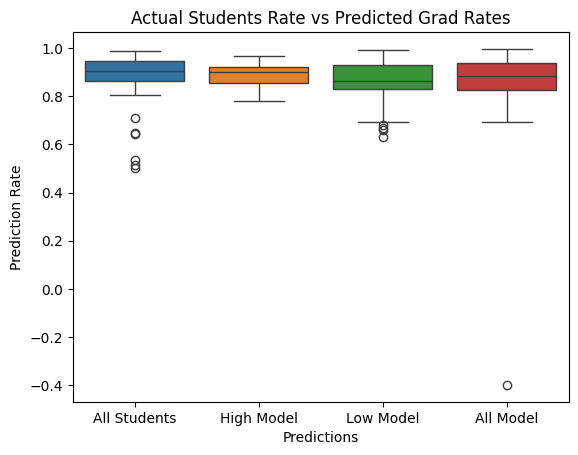

In [89]:
sns.boxplot(data=high_low[['All Students_rate','y_pred_x','y_pred_y','y_pred']].rename(columns={
    'All Students_rate': 'All Students',
    'y_pred_x': 'High Model',
    'y_pred_y': 'Low Model',
    'y_pred': 'All Model'}))
plt.title('Actual Students Rate vs Predicted Grad Rates')
plt.xlabel('Predictions')
plt.ylabel('Prediction Rate')

#Random Forest

###Group 1

In [90]:
rf = RandomForestRegressor(random_state=2026)
rf.fit(X_train,y_train)

RandomForestRegressor(random_state=2026)

In [91]:
rf.score(X_test,y_test)

0.7309199278161769

In [92]:
low['rf_pred'] = rf.predict(X)
low

GROUP_BY_VALUE,Black,Econ Disadv,Hispanic,Male,SwD,Asian,All Students_rate,y_pred,rf_pred
0,0.051515,0.248485,0.072727,0.496970,0.069697,0.115152,0.850515,0.984124,0.896027
1,0.093023,0.413953,0.097674,0.451163,0.111628,0.144186,0.805243,0.943743,0.836212
2,0.074219,0.488281,0.128906,0.539062,0.175781,0.167969,0.805031,0.786070,0.816468
3,0.072961,0.579399,0.141631,0.523605,0.158798,0.175966,0.817544,0.802821,0.826442
4,0.075758,0.446970,0.140152,0.458333,0.193182,0.136364,0.880000,0.851252,0.861995
...,...,...,...,...,...,...,...,...,...
66,0.083821,0.235867,0.081871,0.506823,0.083821,0.077973,0.958879,0.986050,0.954616
67,0.082218,0.210325,0.089866,0.512428,0.105163,0.061185,0.966728,0.971935,0.959729
68,0.070450,0.191781,0.082192,0.524462,0.090020,0.072407,0.969639,0.971207,0.959827
69,0.158940,0.337748,0.099338,0.543046,0.105960,0.152318,0.961783,0.850711,0.933063


In [93]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)

,0
GROUP_BY_VALUE,
Hispanic,0.722096
Econ Disadv,0.078118
Asian,0.066054
Black,0.060801
Male,0.041179
SwD,0.031752


In [94]:
result = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=0)

perm_importance = pd.Series(result.importances_mean, index=X.columns)
perm_importance.sort_values(ascending=False)

,0
GROUP_BY_VALUE,
Hispanic,1.245185
Asian,0.062025
Econ Disadv,0.061681
SwD,0.033988
Black,0.026113
Male,-0.003500


In [95]:
low[['All Students_rate', 'y_pred', 'rf_pred']]

GROUP_BY_VALUE,All Students_rate,y_pred,rf_pred
0,0.850515,0.984124,0.896027
1,0.805243,0.943743,0.836212
2,0.805031,0.786070,0.816468
3,0.817544,0.802821,0.826442
4,0.880000,0.851252,0.861995
...,...,...,...
66,0.958879,0.986050,0.954616
67,0.966728,0.971935,0.959729
68,0.969639,0.971207,0.959827
69,0.961783,0.850711,0.933063


###Group 2

In [96]:
rf2 = RandomForestRegressor(random_state=2026)
rf2.fit(X_train2,y_train2)

RandomForestRegressor(random_state=2026)

In [97]:
rf2.score(X_test2,y_test2)

0.38407099571549586

In [98]:
high['rf_pred'] = rf2.predict(X2)
high

GROUP_BY_VALUE,White,Not Econ Disadv,SwoD,Female,All Students_rate,y_pred,rf_pred
0,0.895161,0.362903,0.766129,0.451613,0.925373,0.888428,0.895531
1,0.910891,0.415842,0.821782,0.435644,0.935185,0.902302,0.900563
2,0.880000,0.350000,0.850000,0.450000,0.917431,0.885066,0.902652
3,0.917431,0.348624,0.862385,0.467890,0.872000,0.884893,0.882533
4,0.836207,0.448276,0.836207,0.465517,0.950820,0.896511,0.934336
...,...,...,...,...,...,...,...
1572,0.833333,0.558824,0.823529,0.460784,0.927273,0.917310,0.920119
1573,0.888889,0.539683,0.777778,0.603175,0.926471,0.893456,0.925434
1574,0.917808,0.630137,0.863014,0.506849,0.948052,0.929525,0.947808
1575,0.850575,0.563218,0.850575,0.597701,1.000000,0.895436,0.961430


In [99]:
importances2 = pd.Series(rf2.feature_importances_, index=X2.columns)
importances2.sort_values(ascending=False)

,0
GROUP_BY_VALUE,
Not Econ Disadv,0.429770
Female,0.220433
White,0.193497
SwoD,0.156300


In [100]:
result2 = permutation_importance(rf2, X_test2, y_test2, n_repeats=10, random_state=0)

perm_importance2 = pd.Series(result2.importances_mean, index=X2.columns)
perm_importance2.sort_values(ascending=False)

,0
GROUP_BY_VALUE,
Not Econ Disadv,0.316528
White,0.136593
Female,0.122635
SwoD,-0.004384


In [101]:
high[['All Students_rate', 'y_pred', 'rf_pred']]

GROUP_BY_VALUE,All Students_rate,y_pred,rf_pred
0,0.925373,0.888428,0.895531
1,0.935185,0.902302,0.900563
2,0.917431,0.885066,0.902652
3,0.872000,0.884893,0.882533
4,0.950820,0.896511,0.934336
...,...,...,...
1572,0.927273,0.917310,0.920119
1573,0.926471,0.893456,0.925434
1574,0.948052,0.929525,0.947808
1575,1.000000,0.895436,0.961430


###Groups Together

In [102]:
rf_all = RandomForestRegressor(random_state=2026)
rf_all.fit(X_train_all,y_train_all)

RandomForestRegressor(random_state=2026)

In [103]:
rf_all.score(X_test_all,y_test_all)

0.7377465218539248

In [104]:
high_low['rf_pred'] = rf_all.predict(X_all)
high_low

GROUP_BY_VALUE,White,Not Econ Disadv,SwoD,Female,All Students_rate,y_pred_x,Black,Econ Disadv,Hispanic,Male,SwD,Asian,y_pred_y,y_pred,rf_pred
0,0.736364,0.751515,0.930303,0.503030,0.850515,0.936739,0.051515,0.248485,0.072727,0.496970,0.069697,0.115152,0.984124,0.957989,0.888315
1,0.641860,0.586047,0.888372,0.548837,0.805243,0.890218,0.093023,0.413953,0.097674,0.451163,0.111628,0.144186,0.943743,0.895494,0.843564
2,0.582031,0.511719,0.824219,0.460938,0.805031,0.886960,0.074219,0.488281,0.128906,0.539062,0.175781,0.167969,0.786070,0.776161,0.830375
3,0.562232,0.420601,0.841202,0.476395,0.817544,0.865863,0.072961,0.579399,0.141631,0.523605,0.158798,0.175966,0.802821,0.780482,0.829265
4,0.602273,0.553030,0.806818,0.541667,0.880000,0.882005,0.075758,0.446970,0.140152,0.458333,0.193182,0.136364,0.851252,0.823635,0.862418
5,0.788018,0.682028,0.907834,0.562212,0.907950,0.918040,0.138249,0.288018,0.168203,0.525346,0.101382,0.103687,0.862626,0.907950,0.907321
6,0.723077,0.729670,0.927473,0.472527,0.951883,0.936981,0.050549,0.270330,0.098901,0.527473,0.072527,0.083516,0.970721,0.971908,0.948253
7,0.692557,0.883495,0.932039,0.459547,0.984076,0.964767,0.093851,0.116505,0.087379,0.540453,0.067961,0.080906,0.955151,0.972903,0.968451
8,0.754864,0.824903,0.912451,0.505837,0.957169,0.951257,0.040856,0.175097,0.095331,0.494163,0.087549,0.075875,0.987572,0.980107,0.956419
9,0.749495,0.824242,0.913131,0.490909,0.974409,0.953308,0.050505,0.175758,0.076768,0.509091,0.086869,0.070707,0.993679,0.996511,0.968379


In [105]:
importances_all = pd.Series(rf_all.feature_importances_, index=X_all.columns)
importances_all.sort_values(ascending=False)

,0
GROUP_BY_VALUE,
Hispanic,0.445946
Asian,0.142091
White,0.126190
Econ Disadv,0.081442
SwD,0.051075
Not Econ Disadv,0.049839
Black,0.046046
SwoD,0.027788
Female,0.017778


In [106]:
result_all = permutation_importance(rf_all, X_test_all, y_test_all, n_repeats=10, random_state=0)

perm_importance_all = pd.Series(result_all.importances_mean, index=X_all.columns)
perm_importance_all.sort_values(ascending=False)

,0
GROUP_BY_VALUE,
Hispanic,0.513529
White,0.153877
Asian,0.116002
Black,0.036318
Econ Disadv,0.026357
SwD,0.020903
SwoD,0.018458
Not Econ Disadv,0.010280
Male,-0.007940


In [107]:
high_low[['All Students_rate', 'y_pred', 'rf_pred']]

GROUP_BY_VALUE,All Students_rate,y_pred,rf_pred
0,0.850515,0.957989,0.888315
1,0.805243,0.895494,0.843564
2,0.805031,0.776161,0.830375
3,0.817544,0.780482,0.829265
4,0.880000,0.823635,0.862418
5,0.907950,0.907950,0.907321
6,0.951883,0.971908,0.948253
7,0.984076,0.972903,0.968451
8,0.957169,0.980107,0.956419
9,0.974409,0.996511,0.968379


#Gaps

In [108]:
full_filtered_pk = filtered_pk.merge(filtered_pk2, how='inner')
full_filtered_pk

,pk,CESA,COHORT,GROUP_BY,GROUP_BY_VALUE,COHORT_COUNT,STUDENT_COUNT,GRAD_RATE
0,740,10.0,2019,All Students,All Students,64,63,0.984375
1,1440,5.0,2019,All Students,All Students,134,124,0.925373
2,6340,2.0,2019,All Students,All Students,25,23,0.920000
3,7040,7.0,2019,All Students,All Students,59,57,0.966102
4,9160,4.0,2019,All Students,All Students,37,33,0.891892
...,...,...,...,...,...,...,...,...
3132,6685160,5.0,2025,All Students,All Students,311,293,0.942122
3133,6685430,5.0,2025,All Students,All Students,57,52,0.912281
3134,6692140,8.0,2025,All Students,All Students,89,85,0.955056
3135,671380,4.0,2025,All Students,All Students,29,29,1.000000


In [109]:
full = filtered_pk_full = filtered_pk_counts.join(filtered_pk_rates.iloc[:,2:], how='inner',rsuffix="_rate")
full

GROUP_BY_VALUE,pk,CESA,COHORT,All Students,Asian,Black,Econ Disadv,Hispanic,Male,SwD,COHORT_rate,All Students_rate,Asian_rate,Black_rate,Econ Disadv_rate,Hispanic_rate,Male_rate,SwD_rate
0,740,10.0,2019,63.0,NaN,NaN,0.603175,NaN,0.460317,NaN,2019,0.984375,NaN,NaN,0.974359,NaN,0.966667,NaN
1,740,10.0,2020,41.0,NaN,NaN,NaN,NaN,NaN,NaN,2020,0.976190,NaN,NaN,NaN,NaN,NaN,NaN
2,740,10.0,2021,52.0,NaN,NaN,NaN,0.500000,0.480769,NaN,2021,0.981132,NaN,NaN,NaN,1.0,0.961538,NaN
3,740,10.0,2022,49.0,NaN,NaN,NaN,NaN,0.530612,NaN,2022,0.980000,NaN,NaN,NaN,NaN,0.962963,NaN
4,740,10.0,2023,55.0,NaN,NaN,0.636364,0.636364,NaN,NaN,2023,1.000000,NaN,NaN,1.000000,1.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3132,81061251,1.0,2020,40.0,NaN,NaN,0.750000,NaN,0.525000,NaN,2020,0.869565,NaN,NaN,0.833333,NaN,0.807692,NaN
3133,81061251,1.0,2021,36.0,NaN,NaN,0.861111,NaN,NaN,NaN,2021,0.857143,NaN,NaN,0.911765,NaN,NaN,NaN
3134,81061251,1.0,2022,60.0,NaN,NaN,0.916667,NaN,0.416667,NaN,2022,0.895522,NaN,NaN,0.901639,NaN,0.833333,NaN
3135,81398139,1.0,2021,13.0,NaN,NaN,NaN,NaN,NaN,NaN,2021,0.382353,NaN,NaN,NaN,NaN,NaN,NaN


###Gender

In [110]:
columns = ['pk','COHORT','CESA','GROUP_BY','GROUP_BY_VALUE','COHORT_COUNT','STUDENT_COUNT','GRAD_RATE']
df = df[columns]

In [111]:
gender = df[(df.GROUP_BY=='Gender')]
gender

,pk,COHORT,CESA,GROUP_BY,GROUP_BY_VALUE,COHORT_COUNT,STUDENT_COUNT,GRAD_RATE
7,740,2019,10.0,Gender,Female,34,34,1.000000
8,740,2019,10.0,Gender,Male,30,29,0.966667
28,1440,2019,5.0,Gender,Female,59,56,0.949153
30,1440,2019,5.0,Gender,Male,75,68,0.906667
52,7040,2019,7.0,Gender,Female,30,30,1.000000
...,...,...,...,...,...,...,...,...
61976,6685430,2025,5.0,Gender,Male,33,31,0.939394
61996,6692140,2025,8.0,Gender,Female,45,44,0.977778
61998,6692140,2025,8.0,Gender,Male,44,41,0.931818
62013,673440,2025,7.0,Gender,Female,42,42,1.000000


In [112]:
gender_wide = gender.pivot(
    index=['pk', 'COHORT','CESA'],
    columns='GROUP_BY_VALUE',
    values='GRAD_RATE'
).reset_index()

In [113]:
gender_wide['gap'] = gender_wide['Female']-gender_wide['Male']
gender_wide

GROUP_BY_VALUE,pk,COHORT,CESA,Female,Male,gap
0,740,2019,10.0,1.000000,0.966667,0.033333
1,740,2021,10.0,1.000000,0.961538,0.038462
2,740,2022,10.0,NaN,0.962963,NaN
3,740,2023,10.0,1.000000,NaN,NaN
4,740,2024,10.0,1.000000,1.000000,0.000000
...,...,...,...,...,...,...
2519,80118127,2024,1.0,0.923077,0.920000,0.003077
2520,80118127,2025,1.0,1.000000,0.822222,0.177778
2521,80238149,2025,2.0,1.000000,NaN,NaN
2522,81061251,2020,1.0,NaN,0.807692,NaN


In [114]:
ttest_1samp(gender_wide['gap'].dropna(), 0)

TtestResult(statistic=np.float64(24.065265037600657), pvalue=np.float64(4.625102422290943e-113), df=np.int64(2074))

In [115]:
fem = gender_wide['Female'].dropna()
male = gender_wide['Male'].dropna()
sdfem = np.std(fem, ddof=1)
sdmale = np.std(male, ddof=1)
n1, n2 = len(fem), len(male)
pooled_sd = np.sqrt(((n1 - 1)*sdfem**2 + (n2 - 1)*sdmale**2) / (n1 + n2 - 2))

In [116]:
gender_gap = gender_wide['gap'].dropna()
gender_d = gender_gap.mean() / pooled_sd
print(f'Cohen\'s D for female vs male students is {gender_d}')

Cohen's D for female vs male students is 0.227228399813392


###Disability

In [117]:
dis = df[(df.GROUP_BY=='Disability Status')]
dis

,pk,COHORT,CESA,GROUP_BY,GROUP_BY_VALUE,COHORT_COUNT,STUDENT_COUNT,GRAD_RATE
16,1440,2019,5.0,Disability Status,SwD,32,29,0.906250
19,1440,2019,5.0,Disability Status,SwoD,102,95,0.931373
45,7040,2019,7.0,Disability Status,SwoD,50,49,0.980000
72,11240,2019,10.0,Disability Status,SwoD,91,87,0.956044
118,14070,2019,9.0,Disability Status,SwD,25,22,0.880000
...,...,...,...,...,...,...,...,...
61935,6685160,2025,5.0,Disability Status,SwD,39,29,0.743590
61938,6685160,2025,5.0,Disability Status,SwoD,272,264,0.970588
61967,6685430,2025,5.0,Disability Status,SwoD,39,38,0.974359
61988,6692140,2025,8.0,Disability Status,SwoD,75,73,0.973333


In [118]:
dis_wide = dis.pivot(
    index=['pk', 'COHORT','CESA'],
    columns='GROUP_BY_VALUE',
    values='GRAD_RATE'
).reset_index()

In [119]:
dis_wide['gap'] = dis_wide['SwoD']-dis_wide['SwD']
dis_wide

GROUP_BY_VALUE,pk,COHORT,CESA,SwD,SwoD,gap
0,740,2022,10.0,NaN,0.977273,NaN
1,740,2023,10.0,NaN,1.000000,NaN
2,740,2024,10.0,NaN,1.000000,NaN
3,740,2025,10.0,NaN,1.000000,NaN
4,1440,2019,5.0,0.90625,0.931373,0.025123
...,...,...,...,...,...,...
2347,80088106,2025,1.0,NaN,0.942857,NaN
2348,80118127,2023,1.0,NaN,0.937500,NaN
2349,80118127,2024,1.0,NaN,0.943396,NaN
2350,80118127,2025,1.0,NaN,0.917808,NaN


In [120]:
ttest_1samp(dis_wide['gap'].dropna(), 0)

TtestResult(statistic=np.float64(53.28972540796826), pvalue=np.float64(7.712483000786191e-263), df=np.int64(784))

In [121]:
swd = dis_wide['SwD'].dropna()
swod = dis_wide['SwoD'].dropna()
swd_sd = np.std(swd, ddof=1)
swod_sd = np.std(swod, ddof=1)
n1, n2 = len(swd), len(swod)
pooled_sd = np.sqrt(((n1 - 1)*swd_sd**2 + (n2 - 1)*swod_sd**2) / (n1 + n2 - 2))

In [122]:
dis_gap = dis_wide['gap'].dropna()
dis_d = dis_gap.mean() / pooled_sd
print(f'Cohen\'s D for student\'s with vs without a disability is {dis_d}')

Cohen's D for student's with vs without a disability is 1.429407449312864


###Econ

In [123]:
econ = df[(df.GROUP_BY=='Economic Status')]
econ

,pk,COHORT,CESA,GROUP_BY,GROUP_BY_VALUE,COHORT_COUNT,STUDENT_COUNT,GRAD_RATE
2,740,2019,10.0,Economic Status,Econ Disadv,39,38,0.974359
4,740,2019,10.0,Economic Status,Not Econ Disadv,25,25,1.000000
21,1440,2019,5.0,Economic Status,Econ Disadv,89,79,0.887640
24,1440,2019,5.0,Economic Status,Not Econ Disadv,45,45,1.000000
47,7040,2019,7.0,Economic Status,Not Econ Disadv,39,38,0.974359
...,...,...,...,...,...,...,...,...
61944,6685160,2025,5.0,Economic Status,Not Econ Disadv,202,198,0.980198
61969,6685430,2025,5.0,Economic Status,Econ Disadv,46,42,0.913043
61991,6692140,2025,8.0,Economic Status,Econ Disadv,39,37,0.948718
61993,6692140,2025,8.0,Economic Status,Not Econ Disadv,50,48,0.960000


In [124]:
econ_wide = econ.pivot(
    index=['pk', 'COHORT','CESA'],
    columns='GROUP_BY_VALUE',
    values='GRAD_RATE'
).reset_index()

In [125]:
econ_wide['gap'] = econ_wide['Not Econ Disadv']-econ_wide['Econ Disadv']
econ_wide

GROUP_BY_VALUE,pk,COHORT,CESA,Econ Disadv,Not Econ Disadv,gap
0,740,2019,10.0,0.974359,1.0,0.025641
1,740,2021,10.0,NaN,1.0,NaN
2,740,2022,10.0,NaN,1.0,NaN
3,740,2023,10.0,1.000000,NaN,NaN
4,740,2024,10.0,1.000000,NaN,NaN
...,...,...,...,...,...,...
2603,80238149,2025,2.0,1.000000,NaN,NaN
2604,81061251,2019,1.0,0.827586,NaN,NaN
2605,81061251,2020,1.0,0.833333,NaN,NaN
2606,81061251,2021,1.0,0.911765,NaN,NaN


In [126]:
ttest_1samp(econ_wide['gap'].dropna(), 0)

TtestResult(statistic=np.float64(35.3160729313837), pvalue=np.float64(2.808816705277227e-202), df=np.int64(1593))

In [127]:
dis = econ_wide['Econ Disadv'].dropna()
notdis = econ_wide['Not Econ Disadv'].dropna()
dis_sd = np.std(dis, ddof=1)
notdis_sd = np.std(notdis, ddof=1)
n1, n2 = len(dis), len(notdis)
pooled_sd = np.sqrt(((n1 - 1)*dis_sd**2 + (n2 - 1)*notdis_sd**2) / (n1 + n2 - 2))

In [128]:
econ_gap = econ_wide['gap'].dropna()
econ_d = econ_gap.mean() / pooled_sd
econ_d

np.float64(0.6485132858013871)

###Race

In [129]:
race = df[(df.GROUP_BY=='Race/Ethnicity')]
race

,pk,COHORT,CESA,GROUP_BY,GROUP_BY_VALUE,COHORT_COUNT,STUDENT_COUNT,GRAD_RATE
12,740,2019,10.0,Race/Ethnicity,White,34,34,1.000000
36,1440,2019,5.0,Race/Ethnicity,White,119,111,0.932773
65,9160,2019,4.0,Race/Ethnicity,White,25,24,0.960000
89,11240,2019,10.0,Race/Ethnicity,White,85,81,0.952941
111,11940,2019,11.0,Race/Ethnicity,White,113,109,0.964602
...,...,...,...,...,...,...,...,...
61930,46960,2025,2.0,Race/Ethnicity,White,44,43,0.977273
61959,6685160,2025,5.0,Race/Ethnicity,White,257,244,0.949416
61982,6685430,2025,5.0,Race/Ethnicity,White,39,35,0.897436
62004,6692140,2025,8.0,Race/Ethnicity,White,69,66,0.956522


In [130]:
race_wide = race.pivot(
    index=['pk', 'COHORT','CESA'],
    columns='GROUP_BY_VALUE',
    values='GRAD_RATE'
).reset_index()
race_wide

GROUP_BY_VALUE,pk,COHORT,CESA,Amer Indian,Asian,Black,Hispanic,Two or More,White
0,740,2019,10.0,NaN,NaN,NaN,NaN,NaN,1.00
1,740,2020,10.0,NaN,NaN,NaN,NaN,NaN,0.96
2,740,2021,10.0,NaN,NaN,NaN,1.000000,NaN,NaN
3,740,2022,10.0,NaN,NaN,NaN,NaN,NaN,1.00
4,740,2023,10.0,NaN,NaN,NaN,1.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2256,80018115,2025,1.0,NaN,NaN,0.714286,0.897727,NaN,NaN
2257,80018124,2021,1.0,NaN,NaN,NaN,0.950000,NaN,NaN
2258,80118127,2023,1.0,NaN,NaN,0.903226,NaN,NaN,NaN
2259,80118127,2024,1.0,NaN,NaN,0.921875,NaN,NaN,NaN


In [131]:
race_wide['gap'] = race_wide['White'] - race_wide['Black']
race_wide[['pk','COHORT','CESA','Black','White','gap']].dropna()

GROUP_BY_VALUE,pk,COHORT,CESA,Black,White,gap
58,14730,2021,6.0,0.586207,0.896679,0.310472
63,14740,2019,6.0,0.769231,0.831325,0.062095
67,14740,2023,6.0,0.593750,0.881657,0.287907
68,14740,2024,6.0,0.629630,0.873333,0.243704
69,14740,2025,6.0,0.740741,0.888268,0.147527
...,...,...,...,...,...,...
2133,6300340,2019,1.0,0.851852,0.936170,0.084318
2135,6300340,2021,1.0,0.941176,0.934066,-0.007111
2136,6300340,2022,1.0,0.814815,0.934911,0.120096
2138,6300340,2024,1.0,0.833333,0.914110,0.080777


In [132]:
ttest_1samp(race_wide['gap'].dropna(), 0)

TtestResult(statistic=np.float64(13.10949471244024), pvalue=np.float64(1.0097329713067677e-29), df=np.int64(231))

In [133]:
white = race_wide['White'].dropna()
black = race_wide['Black'].dropna()
white_sd = np.std(white, ddof=1)
black_sd = np.std(black, ddof=1)
n1, n2 = len(white), len(black)
pooled_sd = np.sqrt(((n1 - 1)*white_sd**2 + (n2 - 1)*black_sd**2) / (n1 + n2 - 2))

In [134]:
race_d = race_wide['gap'].mean() / pooled_sd
print(f'Cohen\'s D for the difference between white and black graduation rates is {race_d}')

Cohen's D for the difference between white and black graduation rates is 0.8431255792078322


In [135]:
race_wide_his = race.pivot(
    index=['pk', 'COHORT','CESA'],
    columns='GROUP_BY_VALUE',
    values='GRAD_RATE'
).reset_index()

In [136]:
race_wide_his['gap'] = race_wide_his['White'] - race_wide_his['Hispanic']
race_wide_his[['pk','COHORT','CESA','Hispanic','White','gap']].dropna()

GROUP_BY_VALUE,pk,COHORT,CESA,Hispanic,White,gap
49,14720,2019,6.0,0.790698,0.894068,0.103370
50,14720,2020,6.0,0.730769,0.890830,0.160060
51,14720,2021,6.0,0.791667,0.860987,0.069320
52,14720,2022,6.0,0.760870,0.881423,0.120553
53,14720,2023,6.0,0.775510,0.890351,0.114841
...,...,...,...,...,...,...
2197,6470100,2024,1.0,1.000000,1.000000,0.000000
2198,6470100,2025,1.0,0.976744,0.983607,0.006862
2203,6678100,2023,5.0,0.923077,0.908257,-0.014820
2204,6678100,2024,5.0,0.933333,0.947826,0.014493


In [137]:
ttest_1samp(race_wide_his['gap'].dropna(), 0)

TtestResult(statistic=np.float64(15.816520138833809), pvalue=np.float64(2.8222300624483114e-46), df=np.int64(519))

In [138]:
white = race_wide['White'].dropna()
hispanic = race_wide['Hispanic'].dropna()
white_sd = np.std(white, ddof=1)
hispanic_sd = np.std(hispanic, ddof=1)
n1, n2 = len(white), len(hispanic)
pooled_sd = np.sqrt(((n1 - 1)*white_sd**2 + (n2 - 1)*hispanic_sd**2) / (n1 + n2 - 2))

In [139]:
his_d = race_wide_his['gap'].mean() / pooled_sd
print(f'Cohen\'s D for the difference between white and hipanic graduation rates is {his_d}')

Cohen's D for the difference between white and hipanic graduation rates is 0.49834343348226917


In [140]:
race_wide_his['gap'].mean()

np.float64(0.04771136330614529)

#Grad Rates vs Test Scores

In [141]:
averages = composite_merged.groupby(['DISTRICT_NAME','COHORT','CESA'])[['Composite_Score','GRAD_RATE']].mean().reset_index()
averages

,DISTRICT_NAME,COHORT,CESA,Composite_Score,GRAD_RATE
0,Galesville-Ettrick-Trempealeau,2020,4.0,2.652779,0.944376
1,Galesville-Ettrick-Trempealeau,2021,4.0,2.268502,0.935271
2,Galesville-Ettrick-Trempealeau,2022,4.0,2.555549,0.946155
3,Galesville-Ettrick-Trempealeau,2023,4.0,2.538167,0.969371
4,Galesville-Ettrick-Trempealeau,2025,4.0,2.682002,0.989433
5,La Crosse,2020,4.0,2.251687,0.873282
6,La Crosse,2021,4.0,2.148800,0.847612
7,La Crosse,2022,4.0,2.173196,0.912027
8,La Crosse,2023,4.0,2.253773,0.890253
9,La Crosse,2025,4.0,2.136825,0.950066


<Axes: xlabel='Composite_Score', ylabel='GRAD_RATE'>

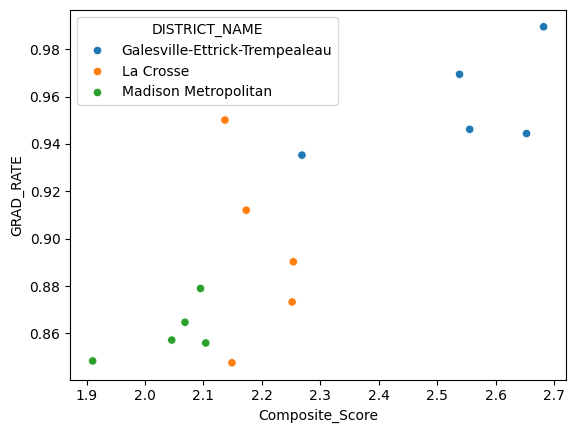

In [158]:
sns.scatterplot(data= averages, x='Composite_Score',y='GRAD_RATE', hue='DISTRICT_NAME')

In [143]:
scores = composite_merged[composite_merged.GRAD_RATE>.7]
scores

,DISTRICT_NAME,GROUP_BY,GROUP_BY_VALUE,COHORT,STUDENT_COUNT,COHORT_COUNT,CESA,EXPECTED_COHORT,TEST_SUBJECT,Composite_Score,GRAD_RATE
0,Galesville-Ettrick-Trempealeau,All Students,All Students,2020,96,103,4.0,2020.0,ELA,2.454545,0.932039
1,Galesville-Ettrick-Trempealeau,All Students,All Students,2020,96,103,4.0,2020.0,Mathematics,2.295455,0.932039
2,Galesville-Ettrick-Trempealeau,All Students,All Students,2020,96,103,4.0,2020.0,Science,2.875000,0.932039
3,Galesville-Ettrick-Trempealeau,All Students,All Students,2020,96,103,4.0,2020.0,Social Studies,2.886364,0.932039
4,Galesville-Ettrick-Trempealeau,All Students,All Students,2021,118,126,4.0,2021.0,ELA,2.172727,0.936508
...,...,...,...,...,...,...,...,...,...,...,...
520,Madison Metropolitan,Race/Ethnicity,White,2023,717,755,2.0,2023.0,Social Studies,2.901382,0.949669
521,Madison Metropolitan,Race/Ethnicity,White,2025,718,759,2.0,2025.0,ELA,2.357189,0.945982
522,Madison Metropolitan,Race/Ethnicity,White,2025,718,759,2.0,2025.0,Mathematics,2.093873,0.945982
523,Madison Metropolitan,Race/Ethnicity,White,2025,718,759,2.0,2025.0,Science,2.672298,0.945982


<Axes: xlabel='Composite_Score', ylabel='GRAD_RATE'>

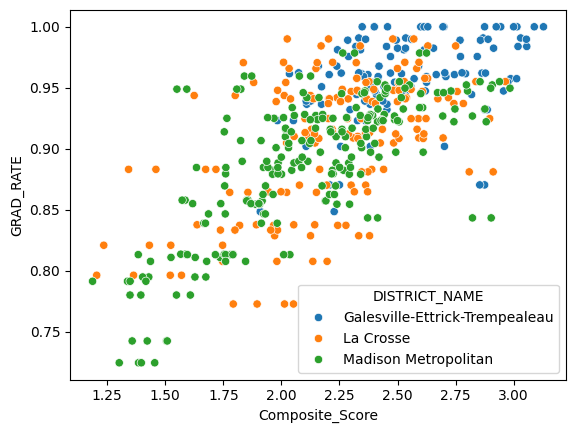

In [144]:
sns.scatterplot(data=scores,y='GRAD_RATE',x='Composite_Score', hue='DISTRICT_NAME')

###Linear Regression

In [145]:
X = scores[['Composite_Score']]
y = scores['GRAD_RATE']

In [146]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state = 2026)

In [147]:
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [148]:
lr.score(X_test,y_test)

0.6396238140872592

In [149]:
scores['y_pred'] = lr.predict(X)
scores

/tmp/ipykernel_5203/2360621808.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scores['y_pred'] = lr.predict(X)


,DISTRICT_NAME,GROUP_BY,GROUP_BY_VALUE,COHORT,STUDENT_COUNT,COHORT_COUNT,CESA,EXPECTED_COHORT,TEST_SUBJECT,Composite_Score,GRAD_RATE,y_pred
0,Galesville-Ettrick-Trempealeau,All Students,All Students,2020,96,103,4.0,2020.0,ELA,2.454545,0.932039,0.931665
1,Galesville-Ettrick-Trempealeau,All Students,All Students,2020,96,103,4.0,2020.0,Mathematics,2.295455,0.932039,0.915624
2,Galesville-Ettrick-Trempealeau,All Students,All Students,2020,96,103,4.0,2020.0,Science,2.875000,0.932039,0.974060
3,Galesville-Ettrick-Trempealeau,All Students,All Students,2020,96,103,4.0,2020.0,Social Studies,2.886364,0.932039,0.975206
4,Galesville-Ettrick-Trempealeau,All Students,All Students,2021,118,126,4.0,2021.0,ELA,2.172727,0.936508,0.903249
...,...,...,...,...,...,...,...,...,...,...,...,...
520,Madison Metropolitan,Race/Ethnicity,White,2023,717,755,2.0,2023.0,Social Studies,2.901382,0.949669,0.976721
521,Madison Metropolitan,Race/Ethnicity,White,2025,718,759,2.0,2025.0,ELA,2.357189,0.945982,0.921849
522,Madison Metropolitan,Race/Ethnicity,White,2025,718,759,2.0,2025.0,Mathematics,2.093873,0.945982,0.895298
523,Madison Metropolitan,Race/Ethnicity,White,2025,718,759,2.0,2025.0,Science,2.672298,0.945982,0.953622


<Axes: >

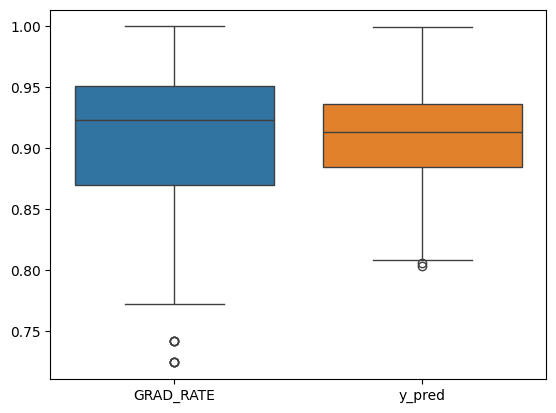

In [150]:
sns.boxplot(data=scores[['GRAD_RATE','y_pred']])

###Plotting

In [151]:
cohort_averages = composite_merged.groupby(['DISTRICT_NAME','CESA','GROUP_BY_VALUE'])[['GRAD_RATE','Composite_Score']].mean().reset_index()
cohort_averages

,DISTRICT_NAME,CESA,GROUP_BY_VALUE,GRAD_RATE,Composite_Score
0,Galesville-Ettrick-Trempealeau,4.0,All Students,0.952920,2.523657
1,Galesville-Ettrick-Trempealeau,4.0,Econ Disadv,0.905012,2.205525
2,Galesville-Ettrick-Trempealeau,4.0,Female,0.978492,2.591961
3,Galesville-Ettrick-Trempealeau,4.0,Male,0.928309,2.454820
4,Galesville-Ettrick-Trempealeau,4.0,Not Econ Disadv,0.971984,2.597078
5,Galesville-Ettrick-Trempealeau,4.0,SwoD,0.974992,2.632611
6,Galesville-Ettrick-Trempealeau,4.0,White,0.964463,2.487157
7,La Crosse,4.0,All Students,0.911956,2.294181
8,La Crosse,4.0,Econ Disadv,0.851103,1.957827
9,La Crosse,4.0,Female,0.935176,2.274162


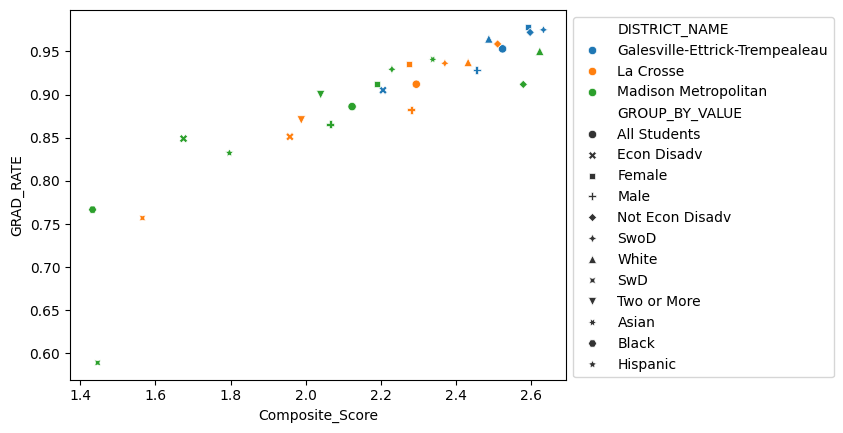

In [152]:
sns.scatterplot(data=cohort_averages,x='Composite_Score',y='GRAD_RATE',hue='DISTRICT_NAME',style='GROUP_BY_VALUE')
plt.legend(bbox_to_anchor=(1, 1))